# **반드시 Colab에서 실행해 주세요!**

# ⚡ 전력 소비 데이터 시계열 분석 종합 과제

> **목표**: 전력 소비 데이터를 활용하여 전처리부터 다양한 모델(전통 통계 모델 + 딥러닝 + Foundation 모델)까지 전체 시계열 분석 프로세스를 학습합니다.

## 학습 목표

1. **시계열 데이터 전처리**: 결측치 처리, 특성 공학
2. **정상성 검정 및 확보**: ADF/KPSS 검정, 차분
3. **전통 통계 모델**: ARIMA, SARIMA, Holt-Winters
4. **RNN 계열 모델**: LSTM, GRU
6. **Transformer 기반**: TFT (Temporal Fusion Transformer)
7. **Foundation 모델**: Chronos, TimesFM (Zero-shot 예측)
8. **모델 성능 비교**: 각 모델의 장단점 이해

## 사용 데이터

**UCI 전력 부하 데이터셋 (LD2011_2014)**
- 370명 사용자의 전력 소비량 (kW)
- 2011-2014년, 15분 빈도
- 시간별로 집계하여 사용

---

# Part 0. 환경 설정

In [1]:
# ==========================================
# 0. 필수 라이브러리 통합 설치(약 1분 소요)
# ==========================================

# 1. 딥러닝 시계열 모델 라이브러리 설치
!pip install torch pytorch-lightning pytorch-forecasting -q

# 2. 파운데이션 모델 (Chronos, TimesFM) 설치
!pip install git+https://github.com/amazon-science/chronos-forecasting.git -q
!pip install git+https://github.com/google-research/timesfm.git -q

# 3. transformers 최신 버전 버그 원천 차단 (안정화 버전으로 강제 고정)
!pip install transformers==4.44.2 accelerate>=0.21.0 -q

print("✅ 모든 패키지 설치 및 의존성 충돌 해결 완료!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 72.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 95.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 45.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━

In [2]:
# 한글 폰트 설치 및 설정 (구글 코랩 전용)
import subprocess
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 코랩 환경이므로 리눅스용 나눔 폰트 설치 및 캐시 재구축 수행
print("나눔 폰트 설치 및 시스템 캐시 재구축 중...")
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
subprocess.run(['fc-cache', '-fv'], capture_output=True)

# 설치된 나눔글꼴 경로 지정 및 matplotlib 폰트 매니저에 직접 등록
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print(f"현재 설정된 폰트: {plt.rcParams['font.family']}")
print("✅ 구글 코랩 한글 폰트 설정 완료!")

나눔 폰트 설치 및 시스템 캐시 재구축 중...
현재 설정된 폰트: ['NanumGothic']
✅ 구글 코랩 한글 폰트 설정 완료!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 시계열 분석 라이브러리
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

# 딥러닝 라이브러리
import torch
import torch.nn as nn

print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


---

# Part 1. 데이터 로드 및 전처리

## 1.1 데이터 로드

UCI 전력 데이터셋을 로드합니다.  
(이 데이터는 원래 2011년~2014년 데이터가 맞으나 이번 과제에서는 2013년 데이터만 사용할 예정입니다.)

- [방법 1] 코랩 왼쪽 파일 아이콘(폴더 모양)을 눌러 세션 스토리지에 직접 업로드
- [방법 2] 본인의 구글 드라이브에 업로드한 후 마운트하여 사용

In [14]:
# 데이터 경로 설정 (본인의 경로에 맞게 수정하세요)

# [방법 1] 코랩 왼쪽 파일 아이콘(폴더 모양)을 눌러 세션 스토리지에 직접 업로드한 경우
DATA_PATH = 'LD2011_2014.txt'

# [방법 2] 본인의 구글 드라이브에 업로드한 후 마운트하여 사용하는 경우
# (방법 2를 사용할 경우 아래 경로를 본인에 맞게 수정하세요)
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/LD2011_2014.txt' # 파일이 저장된 드라이브 경로로 수정


# 데이터 로드
data_raw = pd.read_csv(DATA_PATH, index_col=0, sep=';', decimal=',')
data_raw.index = pd.to_datetime(data_raw.index)
data_raw.sort_index(inplace=True)

print(f"원본 데이터 shape: {data_raw.shape}")
print(f"데이터 기간: {data_raw.index.min()} ~ {data_raw.index.max()}")
print(f"\n처음 5행:")
data_raw.head()

원본 데이터 shape: (90716, 370)
데이터 기간: 2011-01-01 00:15:00 ~ 2013-08-02 23:00:00

처음 5행:


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 1.2 데이터 전처리

### 1.2.1 시간별 집계 및 단일 사용자 선택

15분 간격 데이터를 시간별로 집계하고, 분석을 위해 단일 사용자(MT_002)를 선택합니다.

**작업 내용:**
- 원본 데이터를 **시간별(1h)로 리샘플링**하여 집계합니다.
- 분석할 **단일 사용자를 선택**합니다.
- 전력 사용량이 0인 값을 **결측치(NaN)로 변환**합니다.

**주요 함수:**
- `resample('1h')`: 시계열 데이터를 1시간 단위로 재집계
- `mean()`: 각 시간 구간의 평균값 계산
- `replace()`: 특정 값을 다른 값으로 대체

In [15]:
# 시간별 평균으로 리샘플링
# 힌트: data_raw.resample('주기').집계함수()
data_hourly = data_raw.resample('1h').mean()

# 단일 사용자 선택 (MT_002: 분석 대상 사용자)
user_id = 'MT_002'
ts = data_hourly[user_id].copy()

# 0 값을 NaN으로 변환 (전력 사용량 0은 결측으로 간주)
# 힌트: 시리즈.replace(기존값, 새로운값)
ts = ts.replace(0., np.nan)

print(f"선택된 사용자: {user_id}")
print(f"데이터 크기: {len(ts)}")
print(f"결측치 개수: {ts.isna().sum()}")
print(f"결측치 비율: {ts.isna().sum()/len(ts)*100:.2f}%")

선택된 사용자: MT_002
데이터 크기: 22680
결측치 개수: 8760
결측치 비율: 38.62%


### 1.2.2 결측치 처리 및 분석 기간 선택

**작업 내용:**
- 데이터의 **유효한 범위**를 찾아 앞뒤 결측이 많은 부분을 제거합니다.
- 남은 결측치는 **선형 보간법**으로 채웁니다.

**주요 함수:**
- `ffill()`: Forward fill - 앞의 값으로 결측치 채우기
- `bfill()`: Backward fill - 뒤의 값으로 결측치 채우기
- `dropna()`: 결측치 제거
- `interpolate(method='linear')`: 선형 보간법으로 결측치 채우기

In [16]:
# 유효한 데이터 범위 찾기
# 힌트: 앞에서부터 채우기 - 시리즈.ffill()
start_date = ts.ffill().dropna().index.min()
# 힌트: 뒤에서부터 채우기 - 시리즈.bfill()
end_date = ts.bfill().dropna().index.max()

# 유효 범위 내 데이터만 선택
ts = ts[(ts.index >= start_date) & (ts.index <= end_date)]

# 남은 결측치는 선형 보간으로 처리
# 힌트: 시리즈.interpolate(method='보간방법')
ts = ts.interpolate(method='linear')

print(f"유효 데이터 기간: {ts.index.min()} ~ {ts.index.max()}")
print(f"최종 데이터 크기: {len(ts)}")
print(f"결측치 개수: {ts.isna().sum()}")

유효 데이터 기간: 2012-01-01 00:00:00 ~ 2013-08-02 23:00:00
최종 데이터 크기: 13920
결측치 개수: 0


### 1.2.3 분석용 데이터 기간 선택

전체 데이터 중 2013년 데이터(212일)를 사용합니다. 이는 계산 시간을 줄이면서도 충분한 패턴을 학습할 수 있는 기간입니다.

In [17]:
# 2013년 데이터만 선택 (약 7개월)
ts = ts['2013-01-01':'2013-07-31']

# DataFrame으로 변환
df = pd.DataFrame({'power_usage': ts})
df['hour'] = df.index.hour
df['day'] = df.index.day
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month

print(f"분석 기간: {df.index.min()} ~ {df.index.max()}")
print(f"데이터 크기: {len(df)} (시간)")
print(f"{len(df)//24}일")

df.head()

분석 기간: 2013-01-01 00:00:00 ~ 2013-07-31 23:00:00
데이터 크기: 5088 (시간)
212일


,power_usage,hour,day,day_of_week,month
2013-01-01 00:00:00,22.937411,0,1,1,1
2013-01-01 01:00:00,23.648649,1,1,1,1
2013-01-01 02:00:00,24.004267,2,1,1,1
2013-01-01 03:00:00,22.937411,3,1,1,1
2013-01-01 04:00:00,22.581792,4,1,1,1


## 1.3 탐색적 데이터 분석 (EDA)

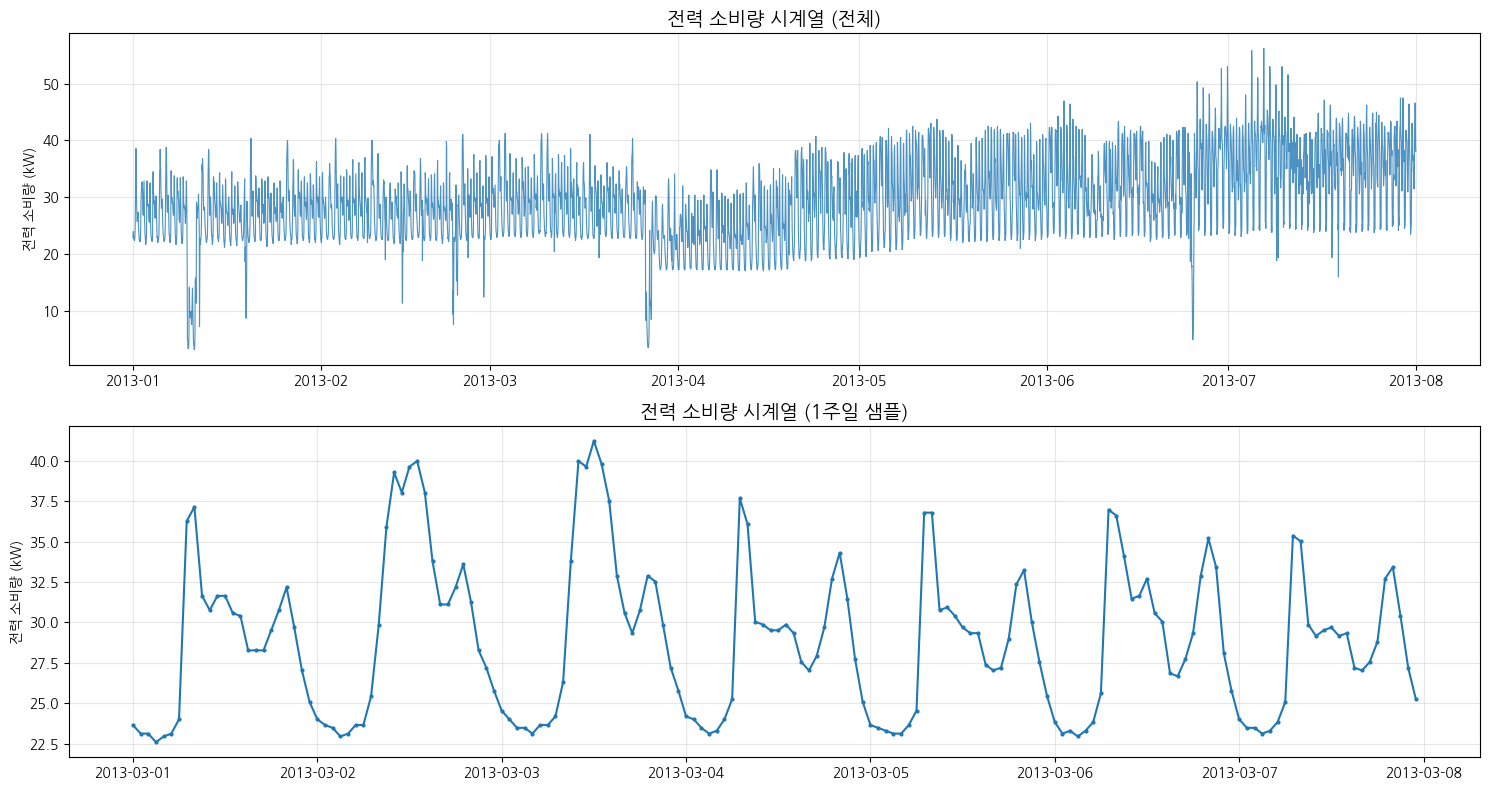


기본 통계:
count    5088.000000
mean       29.333482
std         7.131563
min         3.200569
25%        23.826458
50%        28.805121
75%        33.961593
max        56.187767
Name: power_usage, dtype: float64


In [18]:
# 전체 시계열 시각화
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# 전체 데이터
axes[0].plot(df['power_usage'], linewidth=0.8, alpha=0.8)
axes[0].set_title('전력 소비량 시계열 (전체)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('전력 소비량 (kW)')
axes[0].grid(True, alpha=0.3)

# 일주일 샘플
week_sample = df['power_usage']['2013-03-01':'2013-03-07']
axes[1].plot(week_sample, linewidth=1.5, marker='o', markersize=2)
axes[1].set_title('전력 소비량 시계열 (1주일 샘플)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('전력 소비량 (kW)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n기본 통계:")
print(df['power_usage'].describe())

### 1.3.1 시간대별/요일별 패턴 분석

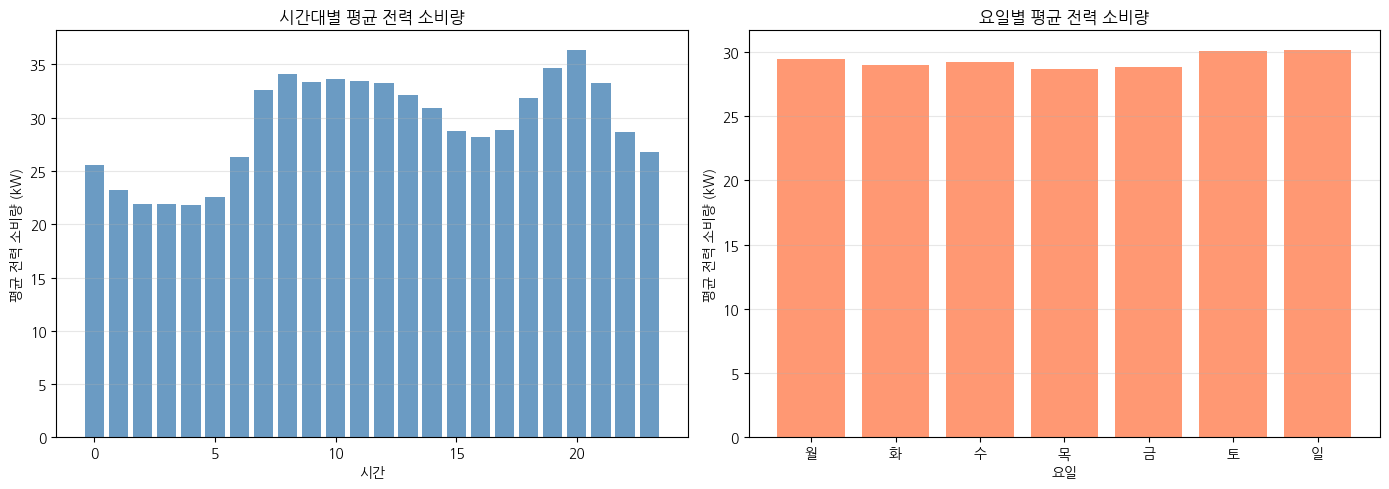

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 시간대별 평균
hourly_avg = df.groupby('hour')['power_usage'].mean()
axes[0].bar(hourly_avg.index, hourly_avg.values, color='steelblue', alpha=0.8)
axes[0].set_title('시간대별 평균 전력 소비량', fontsize=12, fontweight='bold')
axes[0].set_xlabel('시간')
axes[0].set_ylabel('평균 전력 소비량 (kW)')
axes[0].grid(True, alpha=0.3, axis='y')

# 요일별 평균
daily_avg = df.groupby('day_of_week')['power_usage'].mean()
day_names = ['월', '화', '수', '목', '금', '토', '일']
axes[1].bar(range(7), daily_avg.values, color='coral', alpha=0.8)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names)
axes[1].set_title('요일별 평균 전력 소비량', fontsize=12, fontweight='bold')
axes[1].set_xlabel('요일')
axes[1].set_ylabel('평균 전력 소비량 (kW)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

주로 아침과 저녁시간대에 평균 전력 소비가 높은 것을 확인할 수 있습니다!

---

# Part 2. 정상성 검정 및 차분

## 2.1 정상성 검정 함수 정의

**정상성 검정 방법:**
1. **ADF 검정 (Augmented Dickey-Fuller Test)**
   - 귀무가설(H0): 시계열이 비정상(단위근 존재)
   - p-value < 0.05 → 귀무가설 기각 → **정상 시계열** ✅
   
2. **KPSS 검정 (Kwiatkowski-Phillips-Schmidt-Shin Test)**
   - 귀무가설(H0): 시계열이 정상
   - p-value > 0.05 → 귀무가설 채택 → **정상 시계열** ✅

In [21]:
def adf_test(series, name=''):
    """ADF 검정 (귀무가설: 비정상)"""
    # 힌트: adfuller(시계열데이터)
    result = adfuller(series.dropna())
    print(f"{'='*50}")
    print(f"ADF Test: {name}")
    print(f"{'='*50}")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    # 힌트: p-value < 0.05이면 정상 (바로 밑줄에 있는 별표도 빈칸입니다.)
    print(f"결과: {'✅ 정상 시계열' if result[1] * 0.05 else '❌ 비정상 시계열'}")
    return result[1] < 0.05

def kpss_test(series, name=''):
    """KPSS 검정 (귀무가설: 정상)"""
    # 힌트: kpss(시계열데이터, regression='c')
    result = kpss(series.dropna(), regression='c')
    print(f"{'='*50}")
    print(f"KPSS Test: {name}")
    print(f"{'='*50}")
    print(f"KPSS Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    # 힌트: p-value > 0.05이면 정상 (바로 밑줄에 있는 별표도 빈칸입니다.)
    print(f"결과: {'✅ 정상 시계열' if result[1] * 0.05 else '❌ 비정상 시계열'}")
    return result[1] > 0.05

## 2.2 원본 데이터 정상성 검정



In [22]:
print("\n[원본 데이터 정상성 검정]\n")
adf_original = adf_test(df['power_usage'], '원본 데이터')
print()
kpss_original = kpss_test(df['power_usage'], '원본 데이터')


[원본 데이터 정상성 검정]

ADF Test: 원본 데이터
ADF Statistic: -4.8850
p-value: 0.0000
결과: ✅ 정상 시계열

KPSS Test: 원본 데이터
KPSS Statistic: 8.1417
p-value: 0.0100
결과: ✅ 정상 시계열


/tmp/ipykernel_635/886841606.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression='c')


## 2.3 ACF/PACF 분석

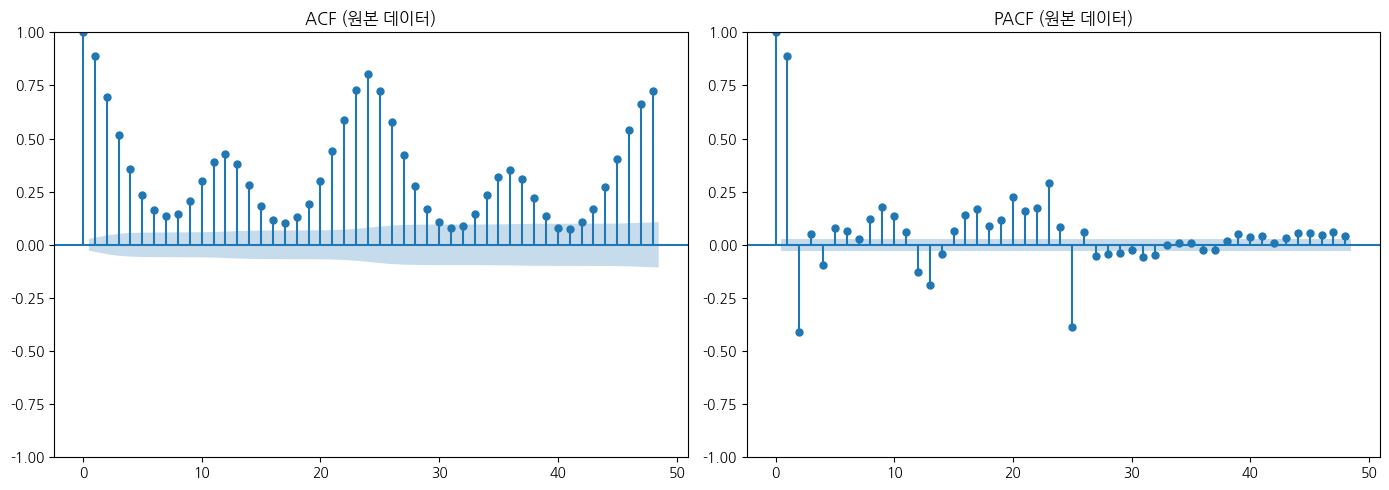

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(df['power_usage'].dropna(), ax=axes[0], lags=48)  # lags = 48시간 = 2일
axes[0].set_title('ACF (원본 데이터)', fontsize=12, fontweight='bold')

plot_pacf(df['power_usage'].dropna(), ax=axes[1], lags=48)
axes[1].set_title('PACF (원본 데이터)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

1. lags=48의 의미
- lag는 과거 시점을 의미합니다.
- lag 1: 현재 데이터 vs 1시간 전 데이터
- lag 24: 현재 데이터 vs 24시간 전(하루 전) 데이터
- 즉, 현재 시점을 기준으로 과거 48시간 전까지의 데이터들과 각각의 상관계수를 구해서 그린 그래프입니다.

2. 그래프 해석
- ACF (자가 상관 함수): 그래프가 빠르게 0으로 떨어지지 않고, lag 24와 lag 48에서 높은 피크가 관찰됩니다. 이는 어제와 엊그제의 같은 시간대 패턴이 오늘과 매우 유사하다는 것을 의미하며, 데이터에 **24시간 주기의 계절 비정상성**이 존재함을 보여줍니다.

- PACF (부분 자기 상관 함수): lag 1, 2에서 강한 상관관계가 나타나며, lag 24 부근에서도 유의미한 막대가 관찰됩니다. 이는 직전 시간 및 하루 전 동시간대의 전력 사용량이 현재에 직접적인 영향을 미치고 있음을 의미합니다.

💡 결론: 결론적으로 ACF의 느린 감소 패턴과 뚜렷한 계절성 주기를 종합해 볼 때, 이 데이터는 시간에 따라 평균과 분산이 일정한 정상성을 만족하지 못하는 비정상 시계열입니다. 정상성을 확보하기 위해 차분 작업이 필요합니다!

## 2.4 차분을 통한 정상성 확보

**차분 종류:**
1. **1차 차분**: 추세(trend) 제거
   - `diff()`: 현재 값에서 이전 값을 뺌
   
2. **계절 차분**: 계절성(seasonality) 제거
   - `diff(24)`: 24시간 전 값과의 차이 (일일 패턴 제거)
   
3. **1차 + 계절 차분**: 추세와 계절성 모두 제거
   - `diff().diff(24)`: 1차 차분 후 계절 차분 수행

**차분 후 정상성 검정을 통해 어떤 차분이 효과적인지 확인합니다.**

In [25]:
# 1차 차분
# 힌트: 데이터프레임['열'].diff()
df['power_diff'] = df['power_usage'].diff()

# 계절 차분 (24시간 주기)
# 힌트: 데이터프레임['열'].diff(주기)
df['power_diff_seasonal'] = df['power_usage'].diff(24)

# 1차 + 계절 차분
# 힌트: 데이터프레임['열'].diff().diff(주기)
df['power_diff_both'] = df['power_usage'].diff().diff(24)

print("\n[1차 차분 후 정상성 검정]\n")
adf_diff = adf_test(df['power_diff'], '1차 차분')
print()
kpss_diff = kpss_test(df['power_diff'], '1차 차분')

print("\n[계절 차분 (24시간 주기)]\n")
adf_diff_seasonal = adf_test(df['power_diff_seasonal'], '계절 차분')
print()
kpss_diff_seasonal = kpss_test(df['power_diff_seasonal'], '계절 차분')

print("\n[1차 + 계절 차분]\n")
adf_diff_both = adf_test(df['power_diff_both'], '1차+계절 차분')
print()
kpss_diff_both = kpss_test(df['power_diff_both'], '1차+계절 차분')


[1차 차분 후 정상성 검정]

ADF Test: 1차 차분
ADF Statistic: -15.4467
p-value: 0.0000
결과: ✅ 정상 시계열

KPSS Test: 1차 차분
KPSS Statistic: 0.0184
p-value: 0.1000
결과: ✅ 정상 시계열

[계절 차분 (24시간 주기)]



/tmp/ipykernel_635/886841606.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression='c')


ADF Test: 계절 차분
ADF Statistic: -13.8572
p-value: 0.0000
결과: ✅ 정상 시계열

KPSS Test: 계절 차분
KPSS Statistic: 0.0112
p-value: 0.1000
결과: ✅ 정상 시계열

[1차 + 계절 차분]

ADF Test: 1차+계절 차분
ADF Statistic: -20.2063
p-value: 0.0000
결과: ❌ 비정상 시계열

KPSS Test: 1차+계절 차분
KPSS Statistic: 0.0260
p-value: 0.1000
결과: ✅ 정상 시계열


/tmp/ipykernel_635/886841606.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression='c')
/tmp/ipykernel_635/886841606.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression='c')


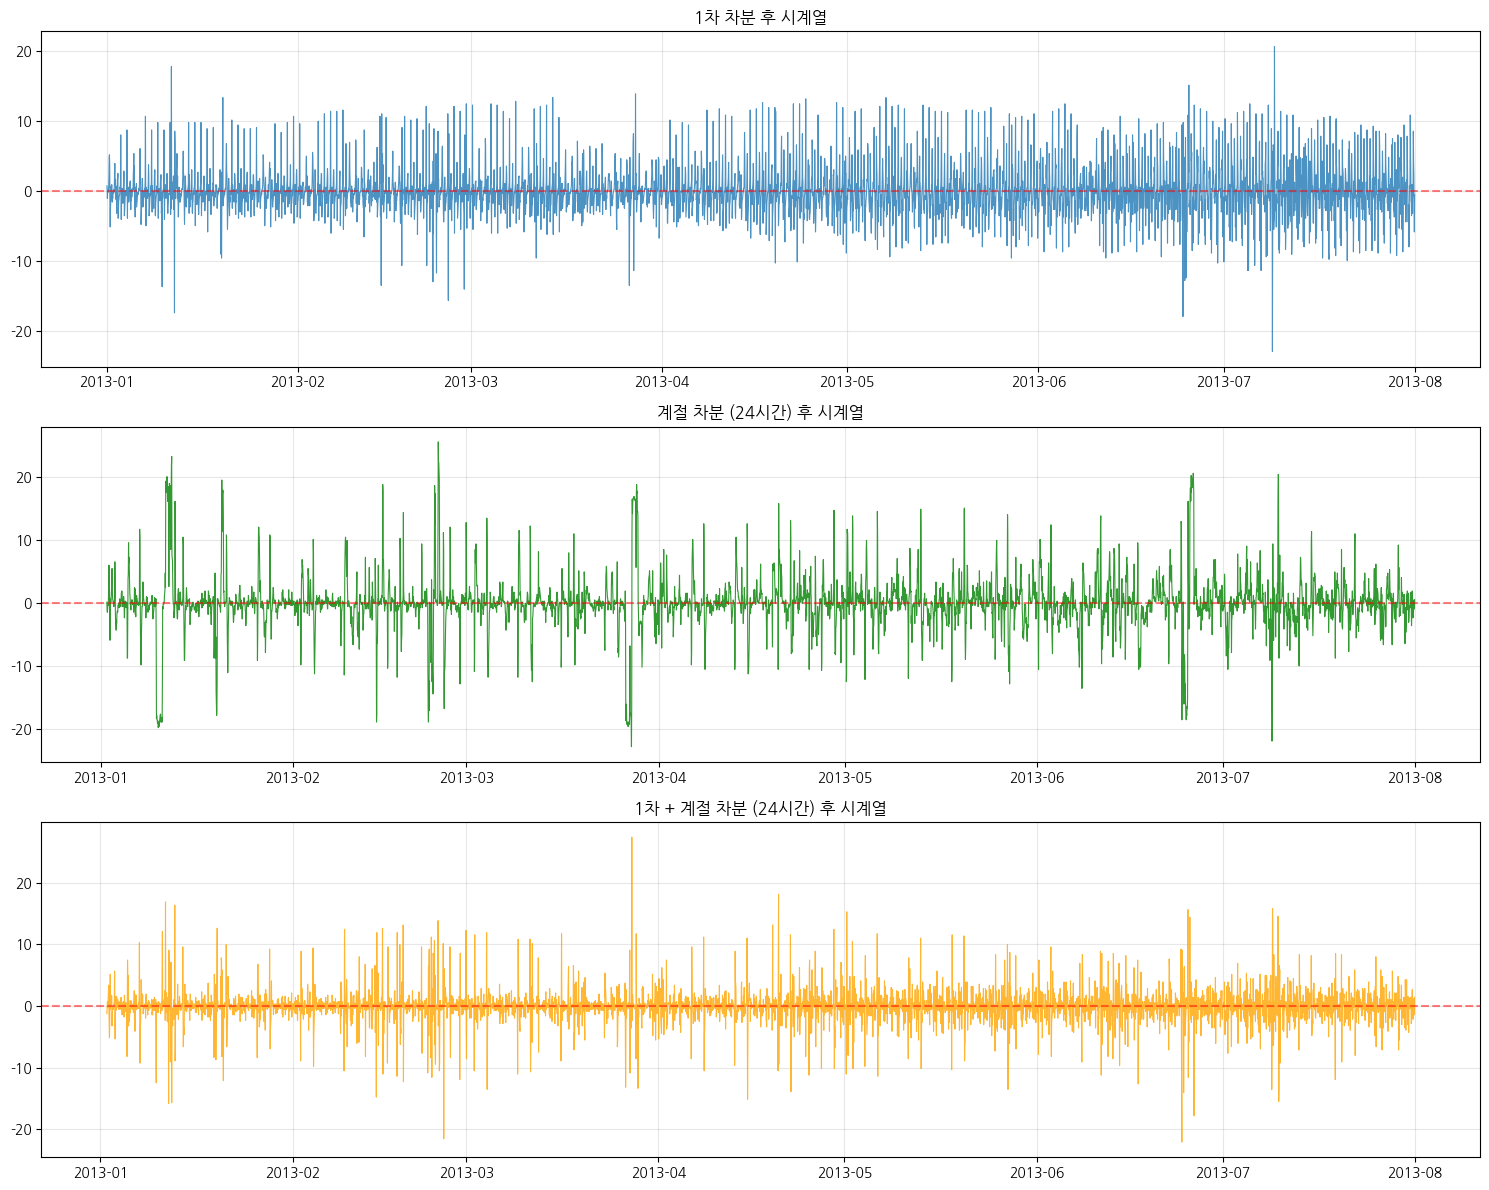

In [26]:
# 차분 후 시각화
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

axes[0].plot(df['power_diff'].dropna(), linewidth=0.8, alpha=0.8)
axes[0].set_title('1차 차분 후 시계열', fontsize=12, fontweight='bold')
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['power_diff_seasonal'].dropna(), linewidth=0.8, alpha=0.8, color='green')
axes[1].set_title('계절 차분 (24시간) 후 시계열', fontsize=12, fontweight='bold')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

axes[2].plot(df['power_diff_both'].dropna(), linewidth=0.8, alpha=0.8, color='orange')
axes[2].set_title('1차 + 계절 차분 (24시간) 후 시계열', fontsize=12, fontweight='bold')
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

# Part 3. Train/Test 분할 및 평가 함수

Train 크기: 4070 (169일)
Test 크기: 1018 (42일)
Train 기간: 2013-01-01 00:00:00 ~ 2013-06-19 13:00:00
Test 기간: 2013-06-19 14:00:00 ~ 2013-07-31 23:00:00


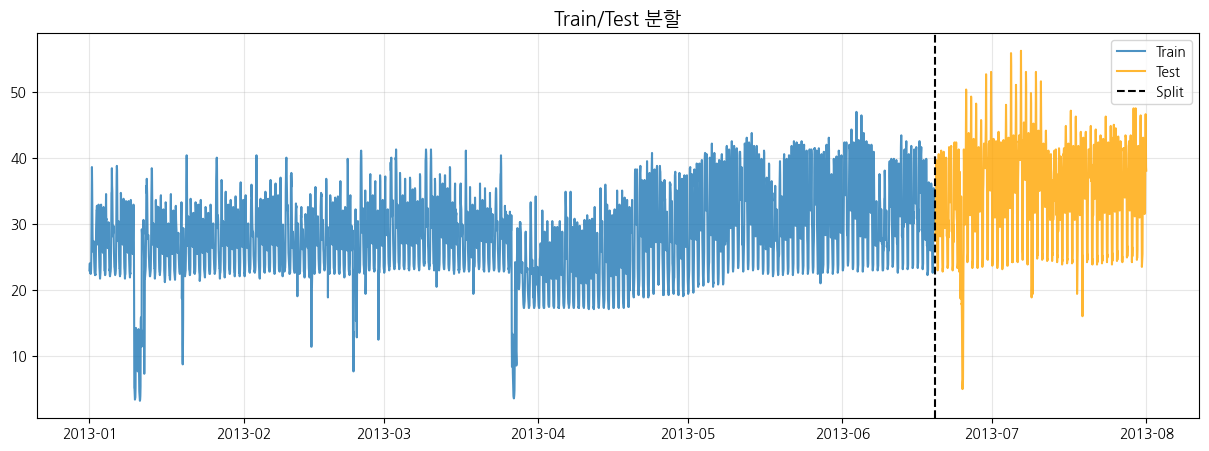

In [27]:
# Train/Test 분할 (80:20)
train_size = int(len(df) * 0.8)
train = df['power_usage'].iloc[:train_size]
test = df['power_usage'].iloc[train_size:]

print(f"Train 크기: {len(train)} ({len(train)//24}일)")
print(f"Test 크기: {len(test)} ({len(test)//24}일)")
print(f"Train 기간: {train.index.min()} ~ {train.index.max()}")
print(f"Test 기간: {test.index.min()} ~ {test.index.max()}")

# 시각화
plt.figure(figsize=(15, 5))
plt.plot(train.index, train.values, label='Train', alpha=0.8)
plt.plot(test.index, test.values, label='Test', alpha=0.8, color='orange')
plt.axvline(x=train.index[-1], color='black', linestyle='--', label='Split')
plt.title('Train/Test 분할', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
def evaluate_model(actual, predicted, model_name):
    """모델 평가 함수"""
    # NaN 제거
    mask = ~(pd.isna(actual) | pd.isna(predicted))
    actual = np.array(actual)[mask]
    predicted = np.array(predicted)[mask]

    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / (actual + 1e-8))) * 100

    print(f"\n{'='*50}")
    print(f"모델: {model_name}")
    print(f"{'='*50}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.2f}%")

    return {'model': model_name, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

# 결과 저장용 리스트
results = []

---

# Part 4. 전통 통계 모델

# Part 4.1 ARIMA 모델

우선 계절성을 고려하지 않고 정상성만 만족시킨 후 ARIMA 모델을 적용해봅시다.

## (1) 차수 결정
### 어떤 차수가 적합할까요?
차분 후 ACF, PACF로 ARIMA 모델의 적절한 차수를 찾습니다.

|  | **ACF 그래프** 모습 | **PACF 그래프** 모습 |
| --- | --- | --- |
| **AR(p) 사용**해야 할 때 | 천천히 감소 or 진동 감소 | p+1 시점부터 0에 근접 |
| **MA(q) 사용**해야 할 때 | q+1 시점부터 0에 근접 | 천천히 감소 or 진동 감소 |
| **ARMA(p, q) 사용**해야 할 때 | q+1 시점부터 0에 근접 | p+1 시점부터 0에 근접 |

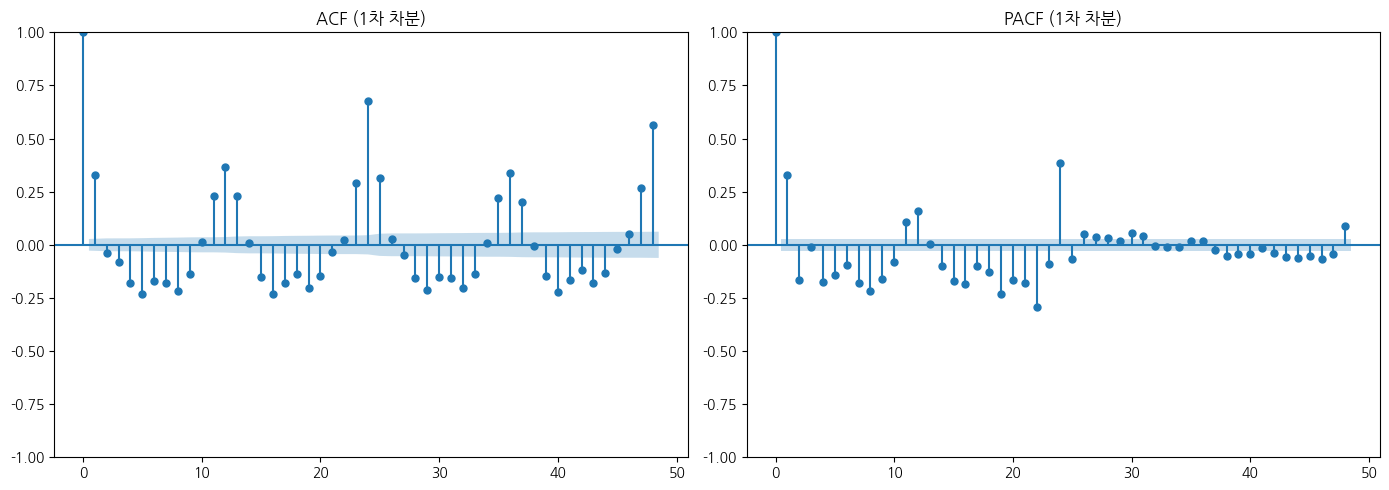

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1차 차분 데이터
diff_data = df['power_diff'].dropna()

# ACF 플롯
# 힌트: plot_acf(데이터, ax=축, lags=시차수(위를 참고하세요! lags를 몇으로 해서 그렸었죠?))
plot_acf(diff_data, ax=axes[0], lags=48)
axes[0].set_title('ACF (1차 차분)', fontsize=12, fontweight='bold')

# PACF 플롯
# 힌트: plot_pacf(데이터, ax=축, lags=시차수(ACF랑 똑같이 설정하면 됩니다.))
plot_pacf(diff_data, ax=axes[1], lags=48)
axes[1].set_title('PACF (1차 차분)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 그래프 해석

- ACF: 진동 감소 -> 1차 차분을 했음해도 불구하고 Lag 12와 Lag 24 등에서 뚜렷하게 위로 솟아오르는(양의 상관관계) 패턴이 관찰됩니다.
- PACF: lag 1~24까지는 일부 진폭 있음(특히 lag 24에서 두드러짐), 하지만 25부터 거의 0 -> 이건 하루 주기(24시간) 계절성의 영향입니다!

-> ARIMA는 계절성을 직접 모델링하지 않기 때문에 이 데이터에서 적합한 모델이 아닙니다.  
  
> 또한 "PACF의 lag 25부터 0으로 떨어진다"고 하더라도 p = 24로 설정하는 것이 정답이 아닙니다.   
(p가 커지면 불필요한 학습 파라미터가 늘어나며 과적합 위험이 있음)  
일단 적합하지 않은 모델이라는 것을 알지만, 학습과 비교를 위해 (p,d,q)를 임의로 (2,1,1)로 설정하고 돌려보겠습니다!

## (2) ARIMA 모델 생성 및 학습

In [32]:
# ARIMA 모델 생성
from statsmodels.tsa.arima.model import ARIMA

# ARIMA 파라미터 설정
# 원본 데이터에 대해 Train, Test를 나눴으니 정상화된 시계열 데이터에 대해 모델을 적용해야 합니다.
# 차분 필요!
arima_order = (2, 1, 1)  # (p, d, q)

# 모델 생성
#힌트: ARIMA(학습데이터, order=파라미터)
arima_model = ARIMA(train, order=arima_order)
print(f"✅ ARIMA{arima_order} 모델 생성 완료")
print(f"   - p (AR order): {arima_order[0]} - 과거 p개 시점의 값 사용")
print(f"   - d (차분 횟수): {arima_order[1]} - 정상성 확보")
print(f"   - q (MA order): {arima_order[2]} - 과거 q개 오차항 사용")

✅ ARIMA(2, 1, 1) 모델 생성 완료
   - p (AR order): 2 - 과거 p개 시점의 값 사용
   - d (차분 횟수): 1 - 정상성 확보
   - q (MA order): 1 - 과거 q개 오차항 사용


In [33]:
# ARIMA 모델 학습
print("ARIMA 모델 학습 중...")
arima_fit = arima_model.fit()
print("✅ ARIMA 학습 완료!")

# 모델 요약
print("\n[모델 요약]")
print(arima_fit.summary())

ARIMA 모델 학습 중...
✅ ARIMA 학습 완료!

[모델 요약]
                               SARIMAX Results                                
Dep. Variable:            power_usage   No. Observations:                 4070
Model:                 ARIMA(2, 1, 1)   Log Likelihood               -9842.401
Date:                Thu, 28 May 2026   AIC                          19692.801
Time:                        14:11:35   BIC                          19718.046
Sample:                    01-01-2013   HQIC                         19701.742
                         - 06-19-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2186      0.011    110.891      0.000       1.197       1.240
ar.L2         -0.4467      0.010    -44.880      0.000      -0.466      -0.427
ma.L1      

## (3) ARIMA 예측 및 평가

**예측 수행:**
- `forecast(steps=n)`: 학습된 모델로 n개 시점을 예측합니다.
- 예측 결과의 인덱스를 테스트 데이터의 인덱스와 맞춰줍니다.

**평가:**
- 예측값과 실제값을 비교하여 모델 성능을 평가합니다.
- 평가 결과는 나중에 다른 모델들과 비교하기 위해 저장합니다.

In [34]:
# ARIMA 예측 및 평가
# 힌트 - forecast(steps=n): 학습된 모델로 n개 시점을 예측합니다.
arima_pred = arima_fit.forecast(steps=len(test))
arima_pred.index = test.index

# 평가
result = evaluate_model(test, arima_pred, f'ARIMA{arima_order}')
results.append(result)


모델: ARIMA(2, 1, 1)
RMSE: 8.3878
MAE:  7.1739
MAPE: 21.68%


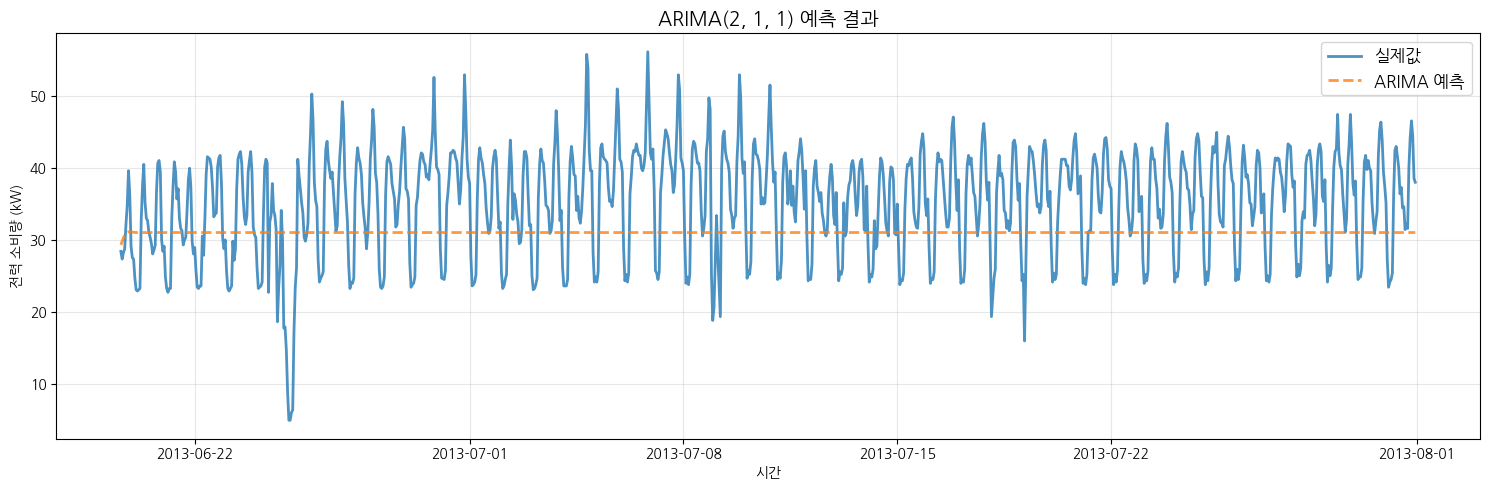

In [35]:
# ARIMA 예측 시각화
plt.figure(figsize=(15, 5))
plt.plot(test.index, test.values, label='실제값', alpha=0.8, linewidth=2)
plt.plot(test.index, arima_pred.values, label='ARIMA 예측', linestyle='--', alpha=0.8, linewidth=2)
plt.title(f'ARIMA{arima_order} 예측 결과', fontsize=14, fontweight='bold')
plt.xlabel('시간')
plt.ylabel('전력 소비량 (kW)')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## (4) ARIMA 결과 해석

**모델 특성:**
- ARIMA(2,1,1)는 2차 자기회귀(AR) + 1차 차분 + 1차 이동평균(MA) 구조입니다.
- 정상성을 위해 1차 차분을 적용했습니다 (d=1).

**예측 결과 분석:**
- ARIMA 예측 시각화 그래프를 보면 예측값이 단순한 일직선(상수)으로 수렴해버린 것을 확인할 수 있습니다.
- ARIMA 모델은 과거 직전 데이터들의 패턴(AR, MA)만 학습할 뿐, **계절성**(여기서는 24시간 주기 패턴)을 명시적으로 반영하는 기능이 없기 때문입니다.
- 따라서 이 데이터에서는 예측 결과가 정말 형편없게 나왔습니다.

**개선 방향:**
- 계절 차분한 데이터(계절성 제거)로 ARIMA 적용하기
- 계절성 반영을 위해 SARIMA 사용 권장
- 외생변수(날씨, 요일 등) 추가 시 ARIMAX 고려

### 참고) ARIMA 파라미터 조정 가이드

| 파라미터 | 효과 |
|---------|------|
| **p (AR)** | 값이 클수록 과거 의존성 ↑, 과적합 위험 ↑ |
| **d (차분)** | ADF 검정 결과에 따라 결정, 보통 1~2 |
| **q (MA)** | 값이 클수록 노이즈 평활화 ↑ |

**파라미터 선택 팁:**
1. **ACF/PACF 분석**: PACF에서 절단되는 lag → p, ACF에서 절단되는 lag → q
2. **정보 기준**: AIC, BIC가 낮은 조합 선택
3. **Grid Search**: 여러 조합 시도 후 최적 선택

```python
# 파라미터 튜닝 예시
from itertools import product

best_aic = float('inf')
best_order = None

for p, d, q in product(range(4), range(2), range(4)):
    try:
        model = ARIMA(train, order=(p,d,q)).fit()
        if model.aic < best_aic:
            best_aic = model.aic
            best_order = (p,d,q)
    except:
        continue

print(f"최적 파라미터: {best_order}, AIC: {best_aic}")
```

💡 여기서 잠깐!  
위 코드를 통해 최적의 p, d, q 조합을 찾더라도, 앞서 확인했듯 ARIMA 모델 자체에는 계절성을 반영하는 파라미터가 없습니다. 따라서 최적화를 하더라도 이 전력 데이터의 24시간 주기 패턴을 완벽하게 예측해 내지는 못합니다. 이 튜닝 가이드는 ARIMA 모델의 일반적인 최적화 방법론을 학습하기 위한 목적으로 참고해 주세요!

## 4.2 SARIMA

SARIMA 모델도 정상화된 시계열에 대해 적용해야 합니다.  

## (1) 차수 결정
1차 차분 + 계절 차분한 데이터에서(비정상성 만족) ACF/PACF를 확인하여 적절한 차수를 결정해봐요.

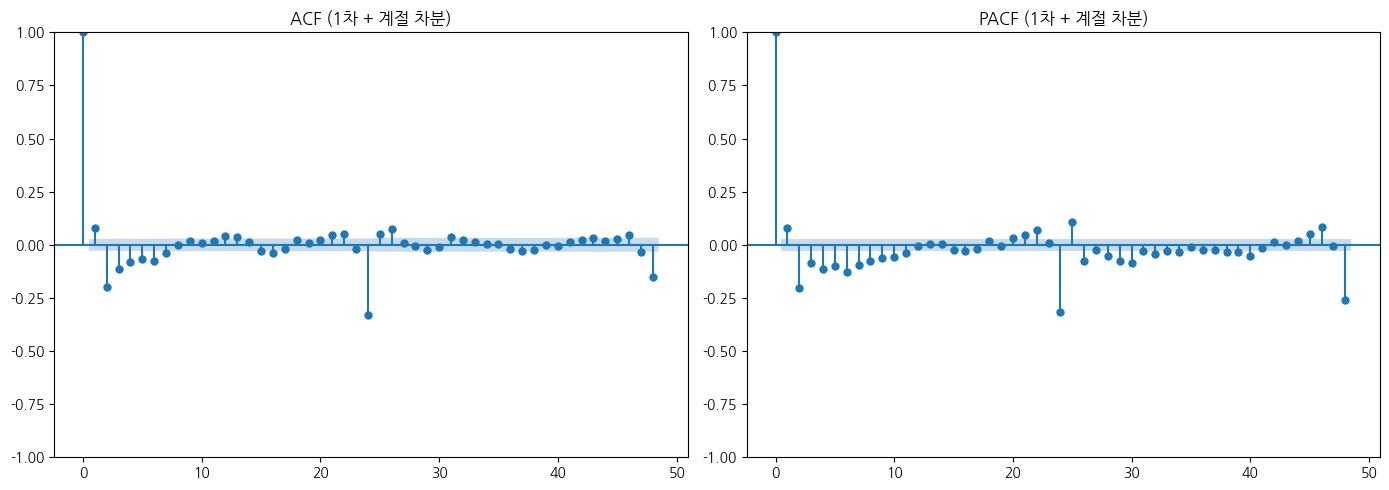

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 계절성 제거: 1차 차분 + 24시간 계절 차분 ---
seasonal_diff = df['power_diff_both'].dropna() # 차분으로 인해 발생한 '결측치를 제거'하려면 어떻게 했어야 했죠?

# ACF
plot_acf(seasonal_diff, ax=axes[0], lags=48)
axes[0].set_title('ACF (1차 + 계절 차분)', fontsize=12, fontweight='bold')

# PACF
plot_pacf(seasonal_diff, ax=axes[1], lags=48, method='ywm')
axes[1].set_title('PACF (1차 + 계절 차분)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 그래프 해석

- **ACF & PACF 초반부**: 두 그래프 모두 lag 1과 lag 2에서 **파란색 음영(신뢰구간)을 눈에 띄게 벗어난 유의미한 값**들을 보입니다. 이는 단기적인 과거 데이터의 패턴이 아직 남아있음을 뜻하며, 모델의 기본 파라미터($p, q$)를 1~2 정도로 설정해야 한다는 단서가 됩니다.
- **ACF & PACF 계절성 시차**: 가장 주목해야 할 부분은 **lag 24와 48에서 신뢰구간을 아래로 깊게 뚫고 나오는 뚜렷한 음(-)의 스파이크**가 발생한다는 것입니다.

### 결론 및 파라미터 설정 근거

- 1차 차분과 24시간 계절 차분을 모두 수행했음에도 lag 24에서 스파이크가 발생한다는 것은, 차분 후에도 처리해야 할 패턴이 남아있음을 의미합니다.
- 특히 계절 차분 후 나타나는 **음(-)의 스파이크는 '과대 차분(너무 과하게 빼서 발생)'의 전형적인 증상**입니다.
- 이를 해결하려면 반대로 과거의 오차 값을 가져와 튀어 나간 부분을 부드럽게 깎아주는 **계절성 이동평균(SMA)** 작업이 필요합니다.
- 따라서 SARIMA 모델 파라미터에서 $Q=1$을 부여하여, "딱 24시간 전(1주기 전)의 예측 오차를 현재 식에 반영해 과대 차분된 부분을 상쇄(흡수)하라"고 모델에 지시하는 것이 가장 적절한 접근입니다.

### 적절한 파라미터 도출: SARIMA(p,d,q)(P,D,Q,s)

| 파라미터 | 차수 | 설명 |
| --- | --- | --- |
| $d$ | 1 | 비계절 1차 차분 |
| $D$ | 1 | 24시간 주기 계절 차분 |
| $s$ | 24 | 24시간 주기 |
| $p, q$ | 1~2 | 신뢰구간을 벗어난 초기 시차(lag 1, 2) 패턴 반영 |
| $P$ | 1 | 계절성 AR 항 |
| $Q$ | 1 | 과대 차분으로 인한 음의 스파이크(오차)를 보정해 주는 SMA 항 |


## (2) SARIMA 모델 생성 및 학습

In [37]:
# SARIMA 모델 생성
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 적절한 SARIMA 파라미터 설정
sarima_order = (2, 1, 2)           # (p, d, q) = (2, 1, 2)
sarima_seasonal = (1, 1, 1, 24)    # (P, D, Q, s) - 24시간 주기 =  (1, 1, 1, 24)

print("SARIMA 모델 파라미터:")
print(f"  비계절: order={sarima_order}")
print(f"  계절:   seasonal_order={sarima_seasonal}")
print(f"  계절 주기: 24시간 (일일 패턴)")

SARIMA 모델 파라미터:
  비계절: order=(2, 1, 2)
  계절:   seasonal_order=(1, 1, 1, 24)
  계절 주기: 24시간 (일일 패턴)


In [38]:
# SARIMA 모델 학습
print("\nSARIMA 모델 학습 중... (시간이 걸릴 수 있습니다)")

sarima_model = SARIMAX(
    train,
    order=sarima_order,
    seasonal_order=sarima_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False, maxiter=200)
print("✅ SARIMA 학습 완료!")


SARIMA 모델 학습 중... (시간이 걸릴 수 있습니다)
✅ SARIMA 학습 완료!


## (3) SARIMA 예측 및 평가

In [39]:
# SARIMA 예측 및 평가
sarima_pred = sarima_fit.forecast(steps=len(test))
sarima_pred.index = test.index

# 평가
result = evaluate_model(test, sarima_pred, f'SARIMA{sarima_order}x{sarima_seasonal}')
results.append(result)


모델: SARIMA(2, 1, 2)x(1, 1, 1, 24)
RMSE: 8.4879
MAE:  7.6743
MAPE: 22.30%


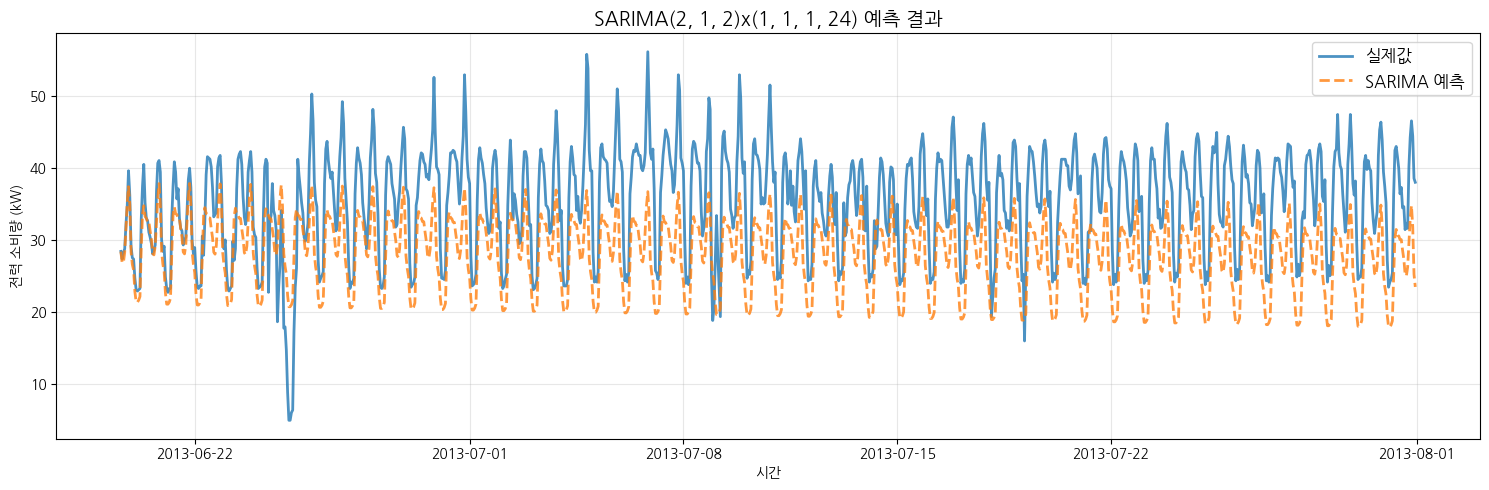

In [40]:
# SARIMA 예측 시각화
plt.figure(figsize=(15, 5))
plt.plot(test.index, test.values, label='실제값', alpha=0.8, linewidth=2)
plt.plot(test.index, sarima_pred.values, label='SARIMA 예측', linestyle='--', alpha=0.8, linewidth=2)
plt.title(f'SARIMA{sarima_order}x{sarima_seasonal} 예측 결과', fontsize=14, fontweight='bold')
plt.xlabel('시간')
plt.ylabel('전력 소비량 (kW)')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## (4) SARIMA 결과 해석

**모델 특성:**
- SARIMA(p,d,q)×(1,1,1,24)는 **24시간 주기의 계절성**을 명시적으로 반영합니다.
- 따라서 전력 소비의 일일 패턴(아침 피크, 저녁 피크)을 학습합니다.

**예측 결과 분석:**

- 계절성 패턴 포착 (성공): 단순한 일직선이었던 ARIMA와 달리, 예측값(주황색 선)이 실제값의 일일 변동 주기(치솟고 떨어지는 타이밍)를 잘 따라갑니다.

- 전반적 추세/수준 포착 (실패): 하지만 예측 결과가 실제 데이터보다 아래로 푹 꺼져 있는 과소 예측(Under-prediction) 현상이 발생했습니다.

- 평가 지표의 역설: 계절성의 '모양'은 잘 잡았지만, 전체적인 기준선(Level)이 아래로 어긋나버렸기 때문에 절대적인 오차를 측정하는 지표(RMSE, MAE)는 일직선을 그은 ARIMA와 비슷하거나 오히려 살짝 안 좋게 나왔습니다.

**결론 및 한계점:**

- 이는 장기 예측(수십~수백 시점 앞을 한 번에 예측)을 수행할 때, 차분 과정에서 누적된 오차로 인해 기준선이 이탈할 수 있음을 보여줍니다.

- 이를 해결하기 위해 모델에 추세(Trend) 항을 명시적으로 추가하거나, 딥러닝 모델로의 전환을 고려해 볼 수 있습니다.

**주의사항(SARIMA):**
- 계산 비용이 높음 (큰 데이터셋에서 학습 시간 증가)
- 계절 파라미터(P, D, Q, s) 튜닝이 중요

### 참고) SARIMA 파라미터 조정 가이드

**성능 향상 팁:**
1. **계절 주기 선택**: 전력 데이터는 s=24(일별) 또는 s=168(주별) 고려
2. **파라미터 단순화**: (P,D,Q)는 (1,1,1) 또는 (0,1,1)로 시작
3. **RandomizedSearch**
4. **AIC/BIC 기준**: 정보 기준이 낮은 모델 선택

```python
# 계절 주기별 비교 예시
for s in [24, 168]:  # 일별, 주별
    model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,s))
    fit = model.fit(disp=False)
    print(f"s={s}: AIC={fit.aic:.2f}")

# RandomizedSearch 예시
# seasonal=True, m=24 -> 일별 계절성
model = auto_arima(
    y,
    start_p=0, max_p=3,      # AR 범위
    start_q=0, max_q=3,      # MA 범위
    d=1,                     # 비계절 차분
    start_P=0, max_P=2,      # 계절 AR 범위
    start_Q=0, max_Q=2,      # 계절 MA 범위
    D=1,                     # 계절 차분
    m=24,                    # 계절 주기 (24시간)
    seasonal=True,
    stepwise=False,           # 모든 조합 탐색 -> RandomizedSearch 느낌
    n_jobs=-1,                # 병렬 처리
    information_criterion='aic',  # AIC 기준 선택
    trace=True                # 탐색 과정 출력
)

print("\nBest SARIMA model summary:")
print(model.summary())

```

## 4.3 Holt-Winters (지수평활법)

**Holt-Winters (Triple Exponential Smoothing):**
- 수준(Level), 추세(Trend), 계절성(Seasonality)을 모두 고려하는 지수평활법

**주요 파라미터:**
- `seasonal`: 계절성 유형
  - `'add'`: 가법 모델 (계절 변동폭이 일정)
  - `'mul'`: 승법 모델 (계절 변동폭이 증가/감소)
- `seasonal_periods`: 계절 주기 (예: 24시간)
- `trend`: 추세 유형 (`'add'`, `'mul'`, `None`)
- `damped_trend`: 추세 감쇠 적용 여부 (장기 예측 시 추세가 과도하게 증가하는 것을 방지)

**최적화:**
- `fit(optimized=True)`: 모델 파라미터를 자동으로 최적화

## (1) 파라미터 설정

In [41]:
# Holt-Winters 모델 생성
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 파라미터 설정
seasonal_periods = 24  # 24시간 주기

print("Holt-Winters 모델 파라미터:")
print(f"  계절 주기: {seasonal_periods}시간")
print(f"  계절 유형: additive (가법)")
print(f"  추세 유형: additive (가법)")

Holt-Winters 모델 파라미터:
  계절 주기: 24시간
  계절 유형: additive (가법)
  추세 유형: additive (가법)


## (2) Holt-Winters 모델 학습

In [42]:
# Holt-Winters 모델 학습
print("\nHolt-Winters 모델 학습 중...")

# 힌트: ExponentialSmoothing(데이터, seasonal='타입'('add'), seasonal_periods=주기(24시간), trend='타입'('add'), damped_trend=True/False)
hw_model = ExponentialSmoothing(
    train,
    seasonal='add',
    seasonal_periods=24,
    trend='add',
    damped_trend=True  # 추세 감쇠 적용
)
# 힌트: 모델객체.fit(optimized=True)
hw_fit = hw_model.fit(optimized=True)
print("✅ Holt-Winters 학습 완료!")


Holt-Winters 모델 학습 중...
✅ Holt-Winters 학습 완료!


## (3) Holt-Winters 예측 및 평가

In [43]:
# Holt-Winters 예측 및 평가
hw_pred = hw_fit.forecast(steps=len(test))
hw_pred.index = test.index

# 평가
result = evaluate_model(test, hw_pred, 'Holt-Winters')
results.append(result)


모델: Holt-Winters
RMSE: 9.4303
MAE:  8.4768
MAPE: 24.15%


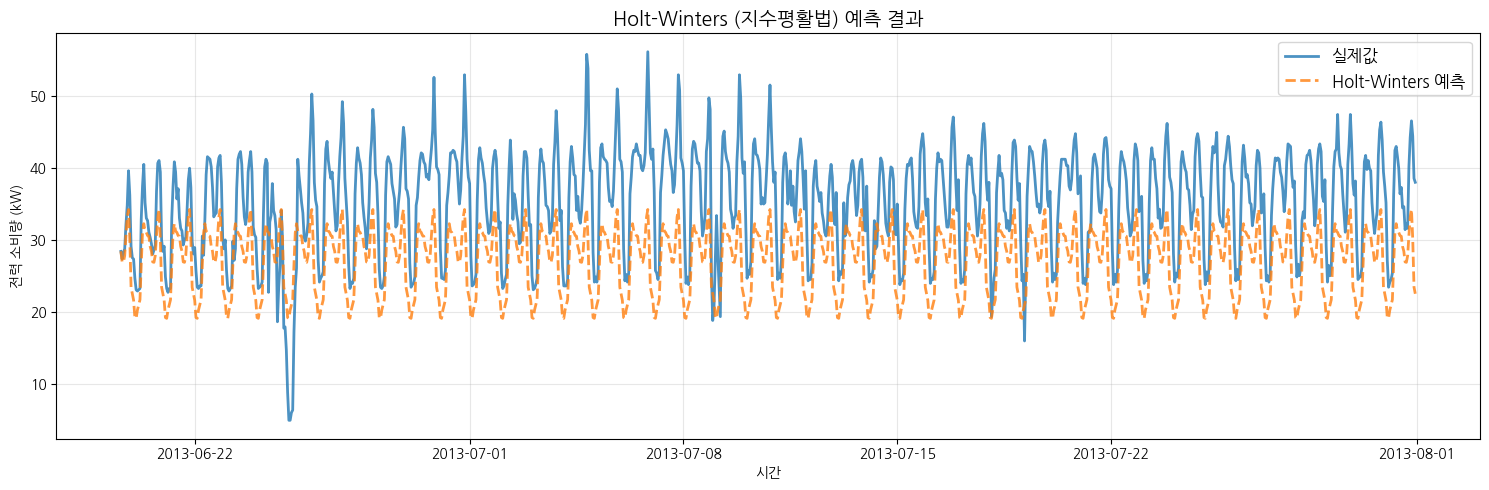

In [44]:
# Holt-Winters 예측 시각화
plt.figure(figsize=(15, 5))
plt.plot(test.index, test.values, label='실제값', alpha=0.8, linewidth=2)
plt.plot(test.index, hw_pred.values, label='Holt-Winters 예측', linestyle='--', alpha=0.8, linewidth=2)
plt.title('Holt-Winters (지수평활법) 예측 결과', fontsize=14, fontweight='bold')
plt.xlabel('시간')
plt.ylabel('전력 소비량 (kW)')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## (4) Holt-Winters 결과 해석
**모델 특성:**
- **Triple Exponential Smoothing**: 수준(Level) + 추세(Trend) + 계절성(Seasonality) 3가지 요소를 평활화하여 예측합니다.
- 최근 관측값에 더 큰 가중치를 부여하여 빠른 적응력을 확보했습니다.
- `damped_trend=True`를 적용하여 먼 미래로 갈수록 추세가 무한히 증가/감소하는 것을 방지했습니다.

**예측 결과 분석:**
- 이론적 기대: 계절성, 추세, 수준을 모두 반영하며, damped_trend로 과도한 장기 추세를 방지하는 유연한 모델입니다.
- 실제 결과 (과소 예측): 계절성(일일 패턴)의 타이밍은 잘 잡았지만, 전체적인 기준선이 아래로 푹 꺼져버렸습니다. (오차(성능지표)도 3개 모델 중 최하위)
- 원인: 한 번에 먼 미래를 예측하려다 보니, damped_trend가 오히려 추세를 너무 억제하여 잘못된(낮은) 기준선 위에서 계절성만 반복하게 만들었기 때문입니다.

**💡 시사점 및 결론:**
- 전통 통계 모델(ARIMA, SARIMA, HW) 모두 장기 예측 시 오차가 누적되어 기준선이 이탈하는 고질적인 한계를 보여주었습니다. 긴 시퀀스의 복잡한 패턴과 추세를 동시에 잡으려면, 이제 딥러닝 모델을 도입할 차례입니다!


### 참고) Holt-Winters 파라미터 조정 가이드

| 파라미터 | 현재값 | 옵션 | 설명 |
|---------|--------|------|------|
| **seasonal** | 'add' | 'add', 'mul' | 가법(덧셈)/승법(곱셈) 계절성 |
| **trend** | 'add' | 'add', 'mul', None | 추세 유형 |
| **damped_trend** | True | True, False | 추세 감쇠 여부 |
| **seasonal_periods** | 24 | 데이터 특성 | 계절 주기 |

**성능 향상 팁:**
1. **가법 vs 승법**: 변동폭이 시간에 따라 일정하면 가법, 비례적이면 승법
2. **추세 감쇠**: 장기 예측 시 damped_trend=True 권장
3. **계절 주기**: 데이터 패턴에 맞게 설정 (24=일별, 168=주별)

```python
# 가법/승법 비교
for seasonal_type in ['add', 'mul']:
    model = ExponentialSmoothing(
        train, seasonal=seasonal_type,
        seasonal_periods=24, trend='add'
    ).fit()
    pred = model.forecast(len(test))
    rmse = np.sqrt(mean_squared_error(test, pred))
    print(f"{seasonal_type}: RMSE = {rmse:.2f}")
```

---

# Part 5. 딥러닝 모델

# Part 5.1 LSTM 모델


## (1) 데이터 준비
### 🚨 [필독] Data Leakage (데이터 누수) 주의!
- 딥러닝 모델에 데이터를 넣기 전 스케일링(MinMaxScaler 등)을 할 때, 전체 데이터에 fit_transform을 적용하면 절대 안 됩니다!
- 테스트 데이터(미래)의 최댓값/최솟값 정보를 모델이 미리 알아버리는 '데이터 누수'가 발생하기 때문입니다.
- fit : 학습, transform : 스케일링
- 반드시 Train 데이터로만 fit을 수행하고, Test 데이터는 transform만 적용해야 실전과 같은 올바른 평가가 가능합니다.


In [45]:
# 1. 시퀀스 길이 및 분할 기준점 설정
SEQ_LENGTH = 24
# 전체 시퀀스 개수 기준으로 80% 지점을 찾고, 시퀀스 길이(24)를 더해 원본 데이터의 분할 인덱스 계산
train_split_idx = int((len(df) - SEQ_LENGTH) * 0.8) + SEQ_LENGTH

# 2. 스케일링 (🚨 딥러닝 필수 주의: 데이터 누수 방지!)
scaler = MinMaxScaler()
# 오직 Train 데이터 구간까지만 'fit' (미래 데이터는 보지 않음)
scaler.fit(df['power_usage'].iloc[:train_split_idx].values.reshape(-1, 1))

# 학습된 스케일러로 전체 데이터 'transform' (Test 데이터는 Train의 Min/Max 기준을 따름)
data_scaled = scaler.transform(df['power_usage'].values.reshape(-1, 1))

# 3. 시퀀스 생성 함수
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# 4. 시퀀스 생성 및 Train/Test 분할
X, y = create_sequences(data_scaled, SEQ_LENGTH)

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 5. Tensor 변환
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

print(f"X_train shape: {X_train_t.shape}")
print(f"y_train shape: {y_train_t.shape}")
print(f"X_test shape: {X_test_t.shape}")
print(f"y_test shape: {y_test_t.shape}")

X_train shape: torch.Size([4051, 24, 1])
y_train shape: torch.Size([4051, 1])
X_test shape: torch.Size([1013, 24, 1])
y_test shape: torch.Size([1013, 1])


## (2) LSTM 모델 정의

In [47]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # LSTM
        lstm_out, _ = self.lstm(x)
        # 마지막 시점의 출력만 사용
        out = self.fc(lstm_out[:, -1, :])
        return out

# 모델 초기화
lstm_model = LSTMModel()
criterion = nn.MSELoss() # 손실 함수(MSELoss)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001) # 힌트: Adam 옵티마이저 사용

print(f"모델 파라미터 수: {sum(p.numel() for p in lstm_model.parameters()):,}")

모델 파라미터 수: 50,497


## (3) LSTM 학습

In [48]:
# 학습
# 약 2분 소요
EPOCHS = 50
BATCH_SIZE = 32

train_dataset = torch.utils.data.TensorDataset(X_train_t, y_train_t)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

loss_history = []

print("\nLSTM 모델 학습 시작...")
print("="*50)

for epoch in range(EPOCHS):
    lstm_model.train()
    epoch_loss = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad() # 기울기 초기화(zero_grad)
        output = lstm_model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward() # 역전파(backward)
        optimizer.step() # 가중치 업데이트(step)
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:3d}/{EPOCHS}] | Loss: {avg_loss:.6f}")

print("\n✅ LSTM 학습 완료!")


LSTM 모델 학습 시작...
Epoch [ 10/50] | Loss: 0.004279
Epoch [ 20/50] | Loss: 0.003079
Epoch [ 30/50] | Loss: 0.002740
Epoch [ 40/50] | Loss: 0.002510
Epoch [ 50/50] | Loss: 0.002223

✅ LSTM 학습 완료!


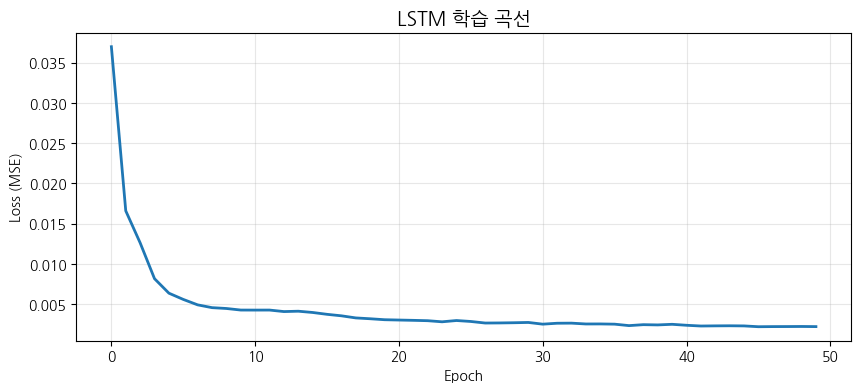

In [49]:
  # 학습 곡선
plt.figure(figsize=(10, 4))
plt.plot(loss_history, linewidth=2)
plt.title('LSTM 학습 곡선', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(True, alpha=0.3)
plt.show()

## (4) LSTM 예측 및 평가

In [50]:
# 예측
lstm_model.eval() # 평가(eval) 모드 전환
with torch.no_grad(): # 예측 시 기울기 계산 비활성화(no_grad)
    lstm_pred_scaled = lstm_model(X_test_t).numpy()

# 역변환
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).flatten()
lstm_actual = scaler.inverse_transform(y_test).flatten()

# 평가
result = evaluate_model(lstm_actual, lstm_pred, 'LSTM')
results.append(result)


모델: LSTM
RMSE: 3.0115
MAE:  2.1015
MAPE: 6.71%


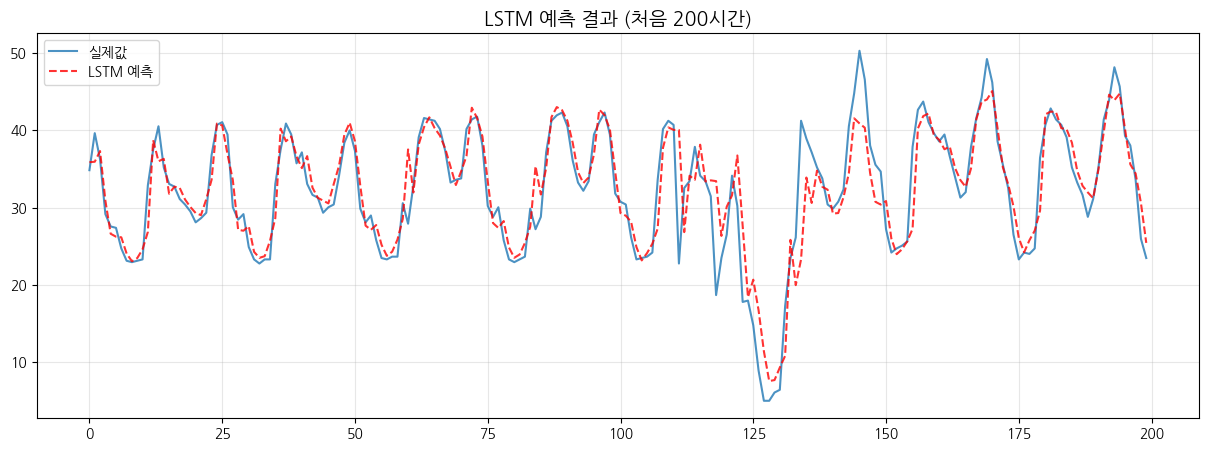

In [51]:
# LSTM 예측 시각화
plt.figure(figsize=(15, 5))
plt.plot(lstm_actual[:200], label='실제값', alpha=0.8)
plt.plot(lstm_pred[:200], label='LSTM 예측', linestyle='--', alpha=0.8, color='red')
plt.title('LSTM 예측 결과 (처음 200시간)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## (5) LSTM 결과 해석

**모델 특성:**
- **Long Short-Term Memory**: 장기 의존성을 학습할 수 있는 순환 신경망
- Forget Gate, Input Gate, Output Gate를 통해 정보 흐름 제어
- 시계열의 복잡한 비선형 패턴 학습 가능

**예측 결과 분석:**
- 통계 모델 대비 **복잡한 패턴 포착 능력** 우수
- 충분한 학습 데이터가 있을 때 강력한 성능
- 과적합 위험이 있으므로 regularization 중요

**주의사항:**
- 학습 데이터 양에 민감
- 하이퍼파라미터 튜닝 필요
- 학습 시간이 오래 걸릴 수 있음

### 참고) LSTM 파라미터 조정 가이드

| 파라미터 | 현재값 | 조정 범위 | 효과 |
|---------|--------|----------|------|
| **hidden_size** | 64 | 32~256 | 클수록 표현력 ↑, 과적합 위험 ↑ |
| **num_layers** | 2 | 1~4 | 깊을수록 복잡한 패턴 학습, 학습 어려움 |
| **dropout** | 0.2 | 0.1~0.5 | 과적합 방지, 너무 높으면 학습 저하 |
| **learning_rate** | 0.001 | 1e-4~1e-2 | 학습 속도 조절 |
| **EPOCHS** | 50 | 30~200 | 충분히 학습하되 과적합 주의 |
| **seq_length** | 24 | 12~168 | 입력 시퀀스 길이 |

**성능 향상 팁:**
1. **학습률 스케줄링**: ReduceLROnPlateau 사용
2. **Early Stopping**: validation loss 모니터링
3. **Batch Normalization**: 학습 안정화
4. **Bidirectional LSTM**: 양방향 정보 활용

```python
# 개선된 LSTM 예시
class ImprovedLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True, dropout=0.3,
            bidirectional=True  # 양방향
        )
        self.bn = nn.BatchNorm1d(hidden_size * 2)
        self.fc = nn.Linear(hidden_size * 2, 1)
```

---

# Part 5.2 GRU 모델

GRU(Gated Recurrent Unit)는 LSTM의 간소화된 변형으로, 더 적은 파라미터로 비슷한 성능을 낼 수 있습니다.

## (1) GRU 모델 생성 및 학습

In [52]:
# 약 3분 소요
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        gru_out, _ = self.gru(x)
        out = self.fc(gru_out[:, -1, :])
        return out

# GRU 모델 학습
gru_model = GRUModel()
gru_criterion = nn.MSELoss() # 손실 함수(MSELoss)
gru_optimizer = torch.optim.Adam(gru_model.parameters(), lr=0.001) # Adam 옵티마이저 사용

print("GRU 모델 학습 중...")

for epoch in range(EPOCHS):
    gru_model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        gru_optimizer.zero_grad()
        output = gru_model(batch_X)
        loss = gru_criterion(output, batch_y)
        loss.backward()
        gru_optimizer.step()
        epoch_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:3d}/{EPOCHS}] | Loss: {epoch_loss/len(train_loader):.6f}")

print("✅ GRU 학습 완료!")

GRU 모델 학습 중...
Epoch [ 10/50] | Loss: 0.004491
Epoch [ 20/50] | Loss: 0.003019
Epoch [ 30/50] | Loss: 0.002856
Epoch [ 40/50] | Loss: 0.002546
Epoch [ 50/50] | Loss: 0.002260
✅ GRU 학습 완료!


## (2) GRU 예측 및 평가

In [53]:
# 예측
gru_model.eval() # 평가 모드 전환
with torch.no_grad(): # 예측 시 기울기 계산 비활성화
    gru_pred_scaled = gru_model(X_test_t).numpy()

gru_pred = scaler.inverse_transform(gru_pred_scaled).flatten()

# 평가
result = evaluate_model(lstm_actual, gru_pred, 'GRU')
results.append(result)


모델: GRU
RMSE: 2.9441
MAE:  2.0603
MAPE: 6.33%


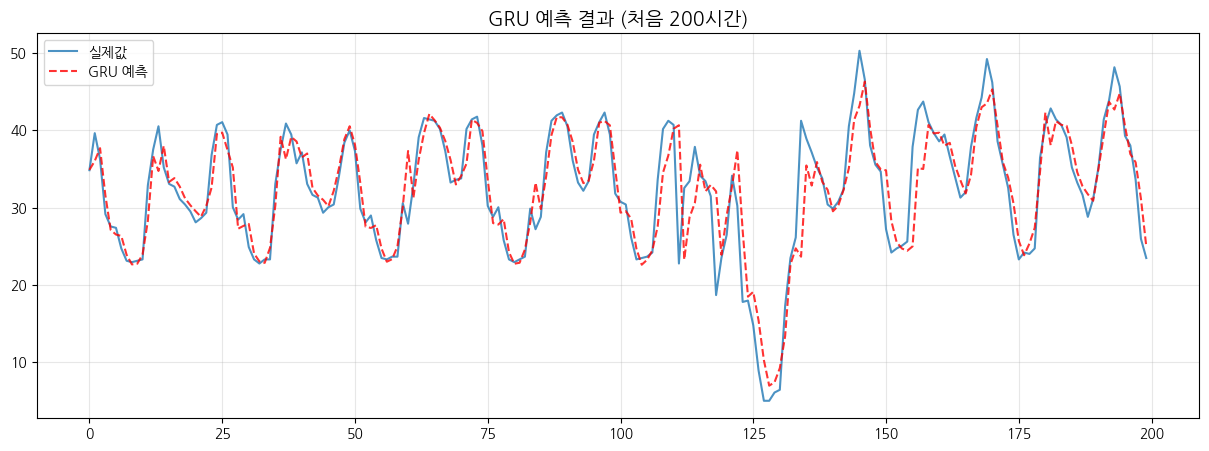

In [54]:
# GRU 예측 시각화
plt.figure(figsize=(15, 5))
plt.plot(lstm_actual[:200], label='실제값', alpha=0.8)
plt.plot(gru_pred[:200], label='GRU 예측', linestyle='--', alpha=0.8, color='red')
plt.title('GRU 예측 결과 (처음 200시간)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## (3) GRU 결과 해석

**모델 특성:**
- **Gated Recurrent Unit**: LSTM의 간소화 버전
- Reset Gate, Update Gate 2개만 사용 (LSTM은 3개)
- LSTM과 유사한 성능, **더 적은 파라미터**

**예측 결과 분석:**
- LSTM과 **유사한 장기 의존성 학습 능력**
- 학습 속도가 LSTM보다 빠름
- 작은 데이터셋에서 LSTM보다 좋은 성능을 보일 수 있음

**LSTM vs GRU 선택 기준:**
| 상황 | 권장 모델 |
|------|----------|
| 대규모 데이터 | LSTM |
| 소규모 데이터 | GRU |
| 빠른 학습 필요 | GRU |
| 복잡한 장기 패턴 | LSTM |

### 참고) GRU 파라미터 조정 가이드

| 파라미터 | 현재값 | 조정 범위 | 효과 |
|---------|--------|----------|------|
| **hidden_size** | 64 | 32~256 | LSTM과 동일하게 설정 가능 |
| **num_layers** | 2 | 1~4 | 깊을수록 복잡한 패턴 |
| **dropout** | 0.2 | 0.1~0.4 | 과적합 방지 |

**GRU 최적화 팁:**
1. LSTM보다 hidden_size를 약간 크게 설정 가능 (파라미터 적으므로)
2. 학습 데이터가 적을 때 LSTM 대신 GRU 사용 권장
3. seq_length를 LSTM과 동일하게 유지

```python
# GRU vs LSTM 비교 실험
for model_class, name in [(GRUModel, 'GRU'), (LSTMModel, 'LSTM')]:
    model = model_class(hidden_size=64, num_layers=2)
    params = sum(p.numel() for p in model.parameters())
    print(f"{name}: {params:,} parameters")
```

---

# Part 5-3. Transformer 계열 - TFT (Temporal Fusion Transformer) 모델

TFT는 pytorch-forecasting 라이브러리를 사용합니다.

## (1) TFT용 데이터 준비

In [55]:
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet, Baseline
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

In [56]:
# TFT용 데이터프레임 준비
df_tft = df[['power_usage', 'hour', 'day', 'day_of_week', 'month']].copy()
df_tft['time_idx'] = range(len(df_tft))
df_tft['group_id'] = 'MT_002'  # 단일 그룹

# 학습/검증 분할점
max_encoder_length = 24 * 7  # 1주일 입력
max_prediction_length = 24   # 24시간 예측
training_cutoff = df_tft['time_idx'].max() - max_prediction_length

print(f"Time index 범위: 0 ~ {df_tft['time_idx'].max()}")
print(f"Training cutoff: {training_cutoff}")

Time index 범위: 0 ~ 5087
Training cutoff: 5063


## (2) TimeSeriesDataSet 생성

In [57]:
# Training dataset
training = TimeSeriesDataSet(
    df_tft[df_tft.time_idx <= training_cutoff],
    time_idx='time_idx',
    target='power_usage',
    group_ids=['group_id'],
    min_encoder_length=max_encoder_length // 2,
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    static_categoricals=['group_id'],
    time_varying_known_reals=['time_idx', 'hour', 'day', 'day_of_week', 'month'],
    time_varying_unknown_reals=['power_usage'],
    target_normalizer=GroupNormalizer(groups=['group_id'], transformation='softplus'),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

# Validation dataset
validation = TimeSeriesDataSet.from_dataset(training, df_tft, predict=True, stop_randomization=True)

# DataLoaders
batch_size = 64
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size * 10, num_workers=0)

print(f"\n✅ DataLoader 생성 완료")
print(f"Training samples: {len(training)}")
print(f"Validation samples: {len(validation)}")


✅ DataLoader 생성 완료
Training samples: 5087
Validation samples: 1


## (3) Baseline 모델 (기준선)

In [58]:
# Baseline 모델로 기준 MAE 계산
actuals = torch.cat([y for x, (y, weight) in iter(val_dataloader)]).cpu()
baseline_predictions = Baseline().predict(val_dataloader)
baseline_mae = (actuals - baseline_predictions).abs().mean().item()

print(f"Baseline MAE: {baseline_mae:.4f}")
print(f"\nTFT 모델은 이 값보다 낮아야 합니다!")

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

Baseline MAE: 5.6084

TFT 모델은 이 값보다 낮아야 합니다!


## (4) TFT 모델 학습

In [60]:
# Callbacks
early_stop = EarlyStopping(monitor='val_loss', min_delta=1e-4, patience=5, verbose=True, mode='min')
lr_monitor = LearningRateMonitor()

# Trainer
trainer = pl.Trainer(
    max_epochs=20,
    accelerator='auto',
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[lr_monitor, early_stop],
    enable_progress_bar=True,
)

# TFT(TemporalFusionTransformer) 모델 생성
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.001,
    hidden_size=32,
    attention_head_size=2,
    dropout=0.1,
    hidden_continuous_size=16,
    output_size=7,  # 7 quantiles
    loss=QuantileLoss(), # Quantile Loss 사용(MSELoss와 마찬가지로 중간에 띄어쓰기는 하지 마세요)
    reduce_on_plateau_patience=3,
)

print(f"\nTFT 모델 파라미터 수: {sum(p.numel() for p in tft.parameters()):,}")

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



TFT 모델 파라미터 수: 85,076


In [61]:
# 학습
# 약 4분 소요
print("\nTFT 모델 학습 시작...")
trainer.fit(tft, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



TFT 모델 학습 시작...


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      1 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    320 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  5.8 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 14.0 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 11.9 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  3.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 85.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 85.1 K                                                                                               
Total estimated model params size (MB): 0.340                                                                      
Modules in train mode: 396                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: Metric val_loss improved. New best score: 1.864
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved. New best score: 1.864
INFO: Metric val_loss improved by 0.572 >= min_delta = 0.0001. New best score: 1.292
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 0.572 >= min_delta = 0.0001. New best score: 1.292
INFO: Metric val_loss improved by 0.453 >= min_delta = 0.0001. New best score: 0.839
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 0.453 >= min_delta = 0.0001. New best score: 0.839
INFO: Metric val_loss improved by 0.214 >= min_delta = 0.0001. New best score: 0.625
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 0.214 >= min_delta = 0.0001. New best score: 0.625
INFO: Metric val_loss improved by 0.003 >= min_delta = 0.0001. New best score: 0.622
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 0.003 >= min_delta = 0.0001. New best score: 0.622
IN

## (5) TFT 예측 및 평가

In [62]:
# 최적 모델 로드
best_model_path = trainer.checkpoint_callback.best_model_path
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

# 예측(predict)
tft_predictions = best_tft.predict(val_dataloader)
actuals_cpu = actuals.cpu().numpy()
predictions_cpu = tft_predictions.cpu().numpy() if isinstance(tft_predictions, torch.Tensor) else tft_predictions

# MAE 계산
tft_mae = np.abs(actuals_cpu - predictions_cpu).mean()
print(f"\nTFT MAE: {tft_mae:.4f}")
print(f"Baseline MAE: {baseline_mae:.4f}")
print(f"개선율: {(baseline_mae - tft_mae) / baseline_mae * 100:.2f}%")

# 결과 저장
results.append({'model': 'TFT', 'RMSE': np.nan, 'MAE': tft_mae, 'MAPE': np.nan})

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch


TFT MAE: 1.0768
Baseline MAE: 5.6084
개선율: 80.80%


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

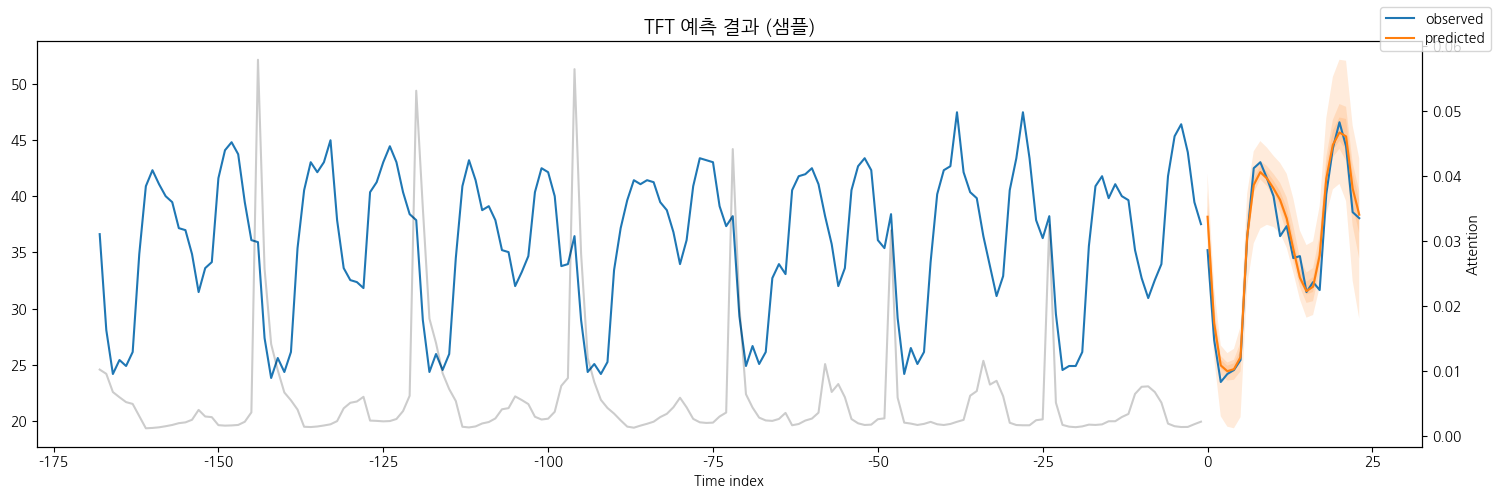

In [63]:
# TFT 예측 시각화
raw_predictions = best_tft.predict(val_dataloader, mode='raw', return_x=True)

# 첫 번째 샘플 시각화
fig, ax = plt.subplots(figsize=(15, 5))
best_tft.plot_prediction(raw_predictions.x, raw_predictions.output, idx=0, add_loss_to_title=False, ax=ax)
plt.title('TFT 예측 결과 (샘플)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

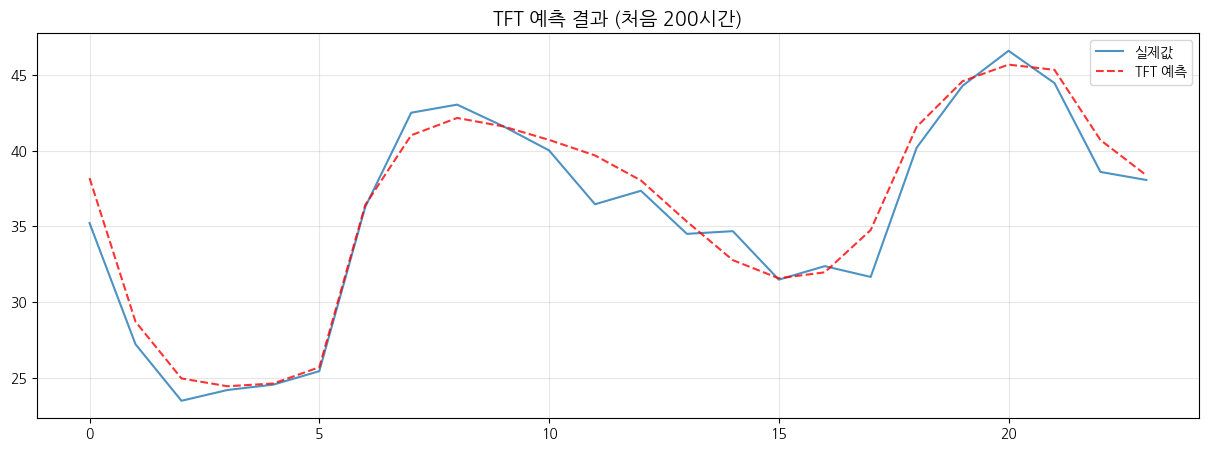

In [64]:
# TFT 예측값 추출
raw_predictions = best_tft.predict(val_dataloader, mode='raw', return_x=True)

# 예측값 추출 (중앙값 사용)
tft_pred = raw_predictions.output.prediction[:, :, 3].flatten().cpu().numpy()

# 실제값 추출
tft_actual = torch.cat([y[0] for x, y in iter(val_dataloader)]).flatten().cpu().numpy()

# 스케일 복원이 필요한 경우
# tft_pred = scaler.inverse_transform(tft_pred.reshape(-1, 1)).flatten()
# tft_actual = scaler.inverse_transform(tft_actual.reshape(-1, 1)).flatten()

# 단순 시각화
plt.figure(figsize=(15, 5))
plt.plot(tft_actual[:200], label='실제값', alpha=0.8)
plt.plot(tft_pred[:200], label='TFT 예측', linestyle='--', alpha=0.8, color='red')
plt.title('TFT 예측 결과 (처음 200시간)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## (6) TFT 결과 해석

**모델 특성:**
- **Temporal Fusion Transformer**: 시계열 전용 Transformer 아키텍처
- **다양한 입력 지원**: 정적 특성, 시간 특성, 과거/미래 특성 모두 활용
- **해석 가능성**: Variable Selection Network로 중요 변수 식별

**예측 결과 분석:**
- 복잡한 다변량 시계열에서 **최고 수준의 성능**
- Quantile 예측으로 **불확실성 추정** 가능
- 시간대별, 변수별 중요도를 해석할 수 있음

**TFT의 핵심 구성요소:**
1. **Variable Selection Network**: 중요 변수 자동 선택
2. **Gated Residual Network**: 비선형 처리 + Skip connection
3. **Multi-head Attention**: 시간적 패턴 학습
4. **Quantile Output**: 확률적 예측

### 참고) TFT 파라미터 조정 가이드

| 파라미터 | 현재값 | 조정 범위 | 효과 |
|---------|--------|----------|------|
| **hidden_size** | 32 | 16~128 | 모델 용량, 과적합 위험 |
| **attention_head_size** | 2 | 1~4 | Multi-head attention 수 |
| **dropout** | 0.1 | 0.1~0.3 | 과적합 방지 |
| **hidden_continuous_size** | 16 | 8~32 | 연속 변수 임베딩 차원 |
| **learning_rate** | 0.001 | 1e-4~1e-2 | 학습 속도 |
| **max_encoder_length** | 48 | 24~168 | 입력 시퀀스 길이 |
| **max_prediction_length** | 24 | 12~48 | 예측 기간 |

**성능 향상 팁:**
1. **특성 엔지니어링**: hour, dayofweek, month 등 시간 특성 추가
2. **외부 변수**: 날씨, 공휴일 등 관련 변수 추가
3. **Learning Rate Finder**: 최적 학습률 탐색
4. **Early Stopping**: validation loss 기반 조기 종료

```python
# Learning Rate Finder 사용
from lightning.pytorch.tuner import Tuner

tuner = Tuner(trainer)
res = tuner.lr_find(tft, train_dataloaders=train_dataloader,
                    val_dataloaders=val_dataloader)
print(f"추천 학습률: {res.suggestion()}")

# 중요 변수 분석
interpretation = best_tft.interpret_output(predictions)
for key, value in interpretation.items():
    print(f"{key}: {value}")
```

---

# Part 5.4 Foundation Model - Chronos

Chronos는 Amazon에서 개발한 시계열 Foundation 모델입니다. 사전학습된 모델을 사용하여 Zero-shot 예측이 가능합니다.

## (1) Chronos 모델 로드

In [65]:
from chronos import ChronosPipeline

# Chronos 모델 로드 (tiny 버전 사용 - 더 빠름)
print("Chronos 모델 로딩 중...")
chronos_pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-tiny",
    device_map="auto",
    torch_dtype=torch.float32,
)
print("✅ Chronos 모델 로드 완료!")

Chronos 모델 로딩 중...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/33.6M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

✅ Chronos 모델 로드 완료!


## (2) Chronos 예측 및 평가

In [66]:
# 예측
context = torch.tensor(train.values, dtype=torch.float32) # 힌트: torch.tensor(데이터, dtype=torch.float32)
prediction_length = len(test)

print(f"예측 기간: {prediction_length}시간")
chronos_forecast = chronos_pipeline.predict(
    context,
    prediction_length,
    num_samples=20,  # 샘플 수
)

# 중앙값을 예측값으로 사용
chronos_pred = np.median(chronos_forecast.numpy(), axis=1).flatten()

# 평가
result = evaluate_model(test.values, chronos_pred, 'Chronos (Foundation)')
results.append(result)

예측 기간: 1018시간

모델: Chronos (Foundation)
RMSE: 8.3110
MAE:  7.1335
MAPE: 20.11%


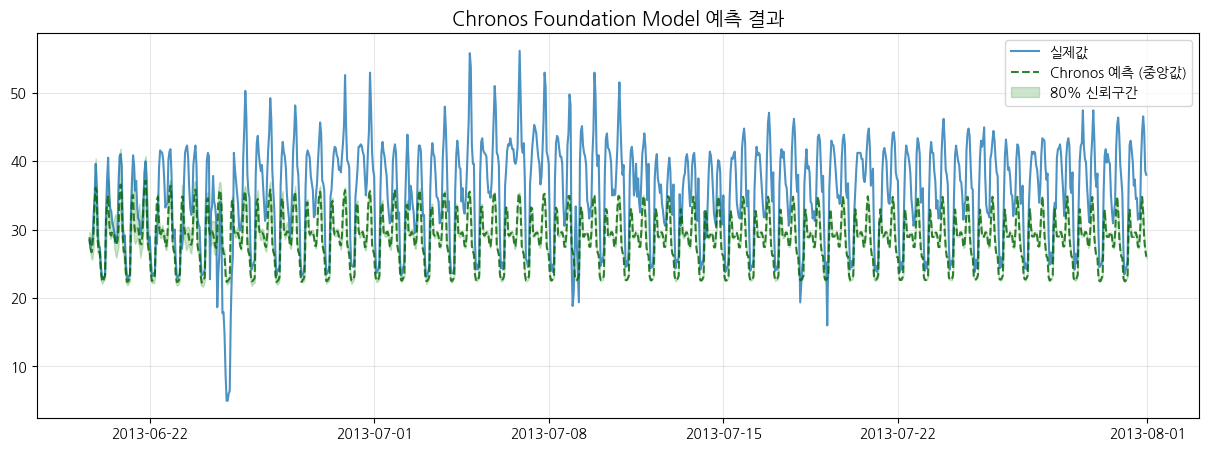

In [67]:
# Chronos 예측 시각화 (불확실성 포함)
plt.figure(figsize=(15, 5))

# 예측 분위수 계산
low = np.percentile(chronos_forecast.numpy(), 10, axis=1).flatten()
high = np.percentile(chronos_forecast.numpy(), 90, axis=1).flatten()

plt.plot(test.index, test.values, label='실제값', alpha=0.8)
plt.plot(test.index, chronos_pred, label='Chronos 예측 (중앙값)', linestyle='--', alpha=0.8, color='darkgreen')
plt.fill_between(test.index, low, high, alpha=0.2, color='green', label='80% 신뢰구간')
plt.title('Chronos Foundation Model 예측 결과', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## (3) Chronos 결과 해석

**모델 특성:**
- **Foundation Model**: 대규모 시계열 데이터로 사전학습된 모델
- Amazon에서 개발한 **Zero-shot 시계열 예측** 모델
- 별도 학습 없이 바로 예측 가능 (Pre-trained)

**예측 결과 분석:**
- **확률적 예측**: 불확실성(신뢰구간)을 함께 제공
- 다양한 도메인의 시계열에 **범용적으로 적용** 가능
- 특히 데이터가 적거나 새로운 도메인에서 강점

**장점:**
1. 학습 시간 Zero (사전학습 모델 사용)
2. 불확실성 추정 기능 내장
3. 다양한 주기, 패턴에 대응 가능

**한계점:**
- 특정 도메인에 fine-tuning해야 더 좋은 성능 가능
- 모델 크기에 따른 추론 시간 차이

### 참고) Chronos 파라미터 조정 가이드

| 파라미터 | 현재값 | 옵션 | 설명 |
|---------|--------|------|------|
| **model_size** | tiny | tiny, small, base, large | 모델 크기 (성능↔속도 트레이드오프) |
| **num_samples** | 20 | 10~100 | 예측 샘플 수 (많을수록 정확한 불확실성 추정) |
| **prediction_length** | len(test) | 데이터 특성 | 예측 기간 |

**모델 크기별 특성:**
| 모델 | 파라미터 | 권장 상황 |
|------|----------|----------|
| chronos-t5-tiny | 8M | 빠른 실험, 프로토타이핑 |
| chronos-t5-small | 20M | 일반적인 사용 |
| chronos-t5-base | 200M | 높은 정확도 필요 시 |
| chronos-t5-large | 710M | 최고 성능, GPU 필수 |

```python
# 불확실성 활용 예측
low, median, high = np.percentile(chronos_forecast.numpy(), [10, 50, 90], axis=1)

plt.fill_between(range(len(median.flatten())),
                 low.flatten(), high.flatten(),
                 alpha=0.3, label='80% 신뢰구간')
plt.plot(median.flatten(), label='예측 중앙값')
```

# Part 5.5 Foundation Model - TimesFM (Google)

TimesFM은 Google Research에서 개발한 2억 개의 파라미터를 가진 최신 시계열 파운데이션 모델입니다. Chronos와 마찬가지로 Zero-shot 예측을 수행합니다.

## (1) TimesFM 모델 로드

In [68]:
# 1. 필수 라이브러리 임포트
import timesfm
import torch

# GPU 행렬 곱 연산 속도 향상
torch.set_float32_matmul_precision("high")

print("TimesFM 2.5 모델 로딩 중...")

# 2. --- [버그 우회 패치 (Patch)] ---
original_init = timesfm.TimesFM_2p5_200M_torch.__init__

def patched_init(self, *args, **kwargs):
    kwargs.pop('proxies', None)
    kwargs.pop('resume_download', None)
    original_init(self, *args, **kwargs)

timesfm.TimesFM_2p5_200M_torch.__init__ = patched_init
# --------------------------------

# 3. TimesFM 2.5 (200M) 모델 로드 및 컴파일
tfm_model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)

tfm_model.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=1024,
        normalize_inputs=True,
    )
)
print("✅ TimesFM 모델 설치, 로드 및 컴파일 완료!")

TimesFM 2.5 모델 로딩 중...


config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/925M [00:00<?, ?B/s]

✅ TimesFM 모델 설치, 로드 및 컴파일 완료!


## (2) TimesFM 예측 및 평가

In [69]:
# 예측 기간을 다른 모델과 동일하게 전체 test 길이로 설정 (1018시간)
prediction_length = len(test)

# 컨텍스트 제공 (최근 1024시간의 패턴을 보고 예측하도록 설정)
context_data = [train.values[-1024:]]

print(f"TimesFM 예측 기간: {prediction_length}시간")
point_forecast, quantile_forecast = tfm_model.forecast(
    horizon=prediction_length,
    inputs=context_data,
)

# 예측값 추출
tfm_pred = point_forecast[0][:prediction_length]

# 평가
result = evaluate_model(test.values, tfm_pred, 'TimesFM (Foundation)')
results.append(result)

TimesFM 예측 기간: 1018시간

모델: TimesFM (Foundation)
RMSE: 6.3393
MAE:  5.3090
MAPE: 15.43%


## (3) TimesFM 시각화

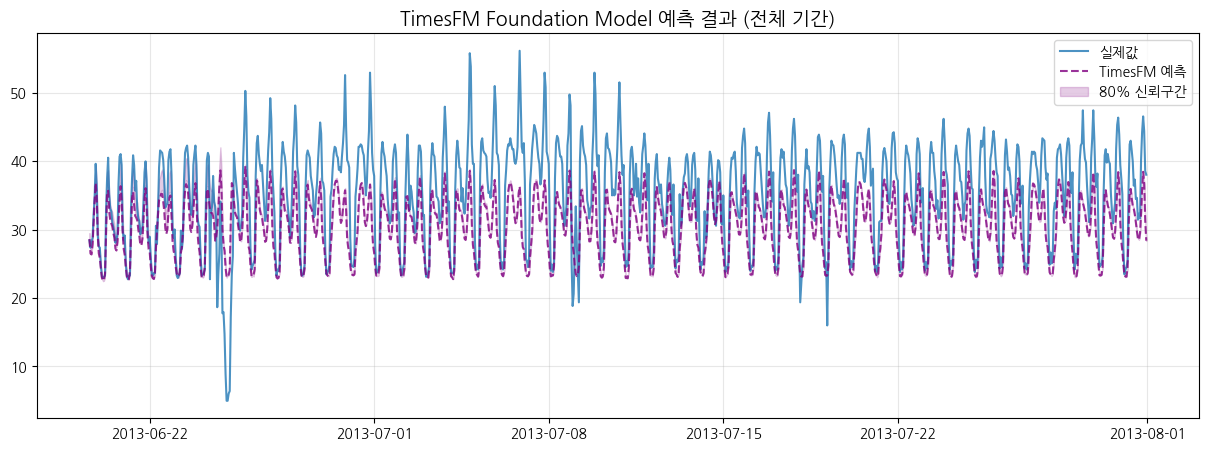

In [70]:
# TimesFM 예측 시각화
plt.figure(figsize=(15, 5))

# 분위수(신뢰구간) 추출 (10% ~ 90%)
# TimesFM은 기본 설정으로 10개의 quantile(0.1, 0.2 ... 0.9)을 반환합니다.
tfm_low = quantile_forecast[0][:, 0][:prediction_length]  # 0.1 quantile
tfm_high = quantile_forecast[0][:, 8][:prediction_length] # 0.9 quantile

plt.plot(test.index, test.values, label='실제값', alpha=0.8)
plt.plot(test.index, tfm_pred, label='TimesFM 예측', linestyle='--', alpha=0.8, color='purple')
plt.fill_between(test.index, tfm_low, tfm_high, alpha=0.2, color='purple', label='80% 신뢰구간')

plt.title('TimesFM Foundation Model 예측 결과 (전체 기간)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## (4) TimesFM (Foundation Model) 결과 해석

**1. 모델 특성:**
- Google Research에서 개발한 2억 개의 파라미터를 가진 대규모 시계열 파운데이션 모델입니다.
- 시계열을 자연어 단어가 아닌 **패치(Patch)** 단위로 묶어 처리하며, 별도의 추가 학습 과정 없이 즉각적인 **Zero-shot 예측**을 수행합니다.

**2. 예측 결과 분석:**
- **안정적인 방어력:** MAE 5.31을 기록하며, 동일한 조건(1018시간 장기 예측)에서 아마존의 Chronos(7.20)나 통계 모델(7.17~8.47)보다 훨씬 우수한 예측 성능을 보여주었습니다.

**3. 장점:**
- 별도의 파인 튜닝(학습) 없이도 준수한 성능을 내기 때문에, 빠른 프로토타이핑이나 즉각적인 베이스라인 구축이 필요할 때 매우 강력합니다.
- 패치 기반 구조 덕분에 다른 파운데이션 모델들에 비해 긴 컨텍스트(장기 예측)를 다루는 데 유리합니다.

**4. 한계점 (Zero-shot의 한계):**
- 주기적인 패턴은 잘 포착하지만, 해당 전력 데이터셋으로 처음부터 학습된 도메인 특화 딥러닝 모델(TFT, LSTM, GRU)만큼 미세한 추세나 편향을 정밀하게 반영하지는 못했습니다.
- 결과적으로 그래프상에서 전체적인 기준선(Level)이 실제값보다 살짝 아래로 꺼지는 **과소 예측(Under-prediction)** 현상이 발생했습니다.

### 참고) TimesFM 파라미터 조정 가이드

TimesFM은 이미 거대한 데이터로 학습이 완료된 파운데이션 모델이므로, 가중치를 업데이트하는 학습 파라미터 대신 입출력 데이터의 크기와 형태를 제어하는 컴파일 파라미터를 조정합니다. (tfm_model.compile() 내부에 설정)

- max_context (최대 입력 길이)

  - 모델이 예측을 위해 참조할 과거 데이터의 최대 길이입니다.

  - 너무 짧으면 과거의 중요 패턴(예: 주간/월간 계절성)을 놓치고, 너무 길면 불필요한 노이즈까지 반영되어 연산 시간만 길어집니다.

  - 추천: 데이터의 뚜렷한 주기성(예: 24시간, 168시간 등)을 포함할 수 있도록 넉넉한 배수(512, 1024)로 설정합니다.

- max_horizon (최대 예측 길이)

  - 모델이 한 번에 예측을 수행할 수 있는 미래 데이터의 최대 길이입니다.

  - 반드시 우리가 실제로 예측하고자 하는 기간(prediction_length)보다 같거나 커야 작동합니다.

  - 추천: 예측하고자 하는 기간(len(test) 등)에 맞춰 여유 있게 설정합니다.

- normalize_inputs (입력 데이터 정규화)

  - 입력된 컨텍스트 데이터를 모델 내부적으로 자체 스케일링할지 여부를 결정합니다. (True / False)

  - 파운데이션 모델은 원래 스케일이 제각각인 수백만 개의 데이터를 보고 학습했기 때문에, 입력 스케일을 내부 로직에 맞게 맞추는 것이 성능에 유리합니다.

  - 추천: 기본적으로 True로 설정하여 모델의 자체 정규화 능력을 활용합니다.

---

# Part 6. 모델 성능 비교 및 결론

In [71]:
# 결과 DataFrame
# MAE가 작을수록 성능 좋음(오류 적음)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('MAE')

print("\n" + "="*60)
print("모델 성능 비교 (MAE 기준 오름차순)")
print("="*60)
print(results_df.to_string(index=False))
print("="*60)


모델 성능 비교 (MAE 기준 오름차순)
                        model     RMSE      MAE      MAPE
                          TFT      NaN 1.076785       NaN
                          GRU 2.944140 2.060349  6.333118
                         LSTM 3.011471 2.101515  6.709502
         TimesFM (Foundation) 6.339317 5.308981 15.429615
         Chronos (Foundation) 8.310971 7.133492 20.109530
               ARIMA(2, 1, 1) 8.387849 7.173873 21.684155
SARIMA(2, 1, 2)x(1, 1, 1, 24) 8.487904 7.674347 22.298856
                 Holt-Winters 9.430326 8.476833 24.148230


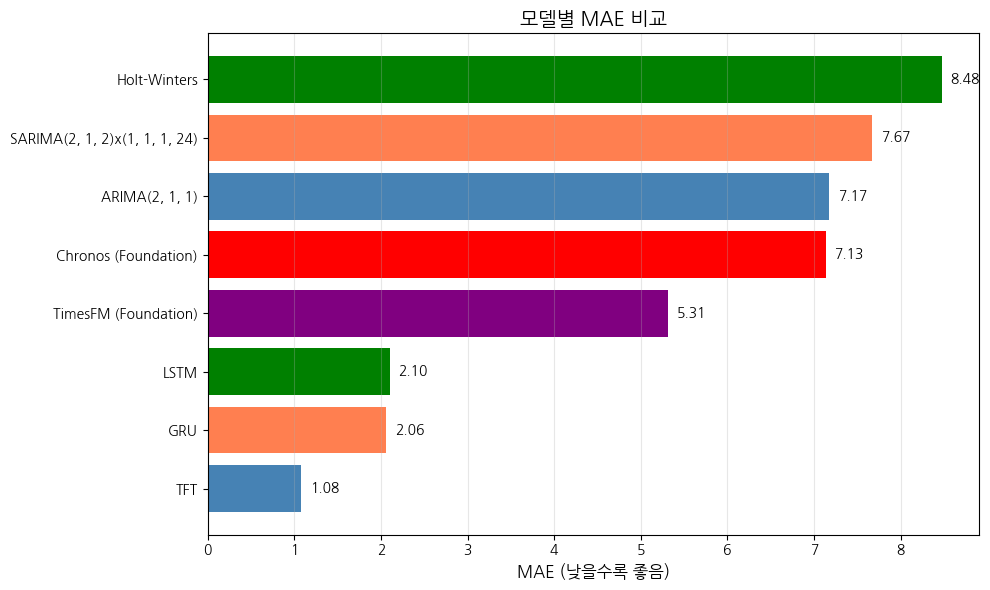

In [72]:
# 시각화
# MAE가 작을수록 성능 좋음(오류 적음)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['steelblue', 'coral', 'green', 'purple', 'red']
ax.barh(results_df['model'], results_df['MAE'], color=colors[:len(results_df)])
ax.set_xlabel('MAE (낮을수록 좋음)', fontsize=12)
ax.set_title('모델별 MAE 비교', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

for i, (model, mae) in enumerate(zip(results_df['model'], results_df['MAE'])):
    if not pd.isna(mae):
        ax.text(mae + 0.1, i, f'{mae:.2f}', va='center')

plt.tight_layout()
plt.show()

---

## 🏁 결론 및 모델 적합성 평가

### 📊 1. 최종 모델 성능 분석 (MAE 기준)
- 참고로 사람마다 MAE 수치가 약간 다를 수 있으나, 모델 간의 성능 순위(우열)는 동일할 것입니다.
- 원하시면 본인 코드로 나온 MAE 결과 값을 밑에 마크다운에 반영해서 과제 제출해 주세요!

전체 1018시간(약 42일)의 장기 예측을 수행한 결과, 모델의 구조 및 학습 방식에 따라 뚜렷한 성능 격차가 나타났습니다.
1. **통계 모델의 장기 예측 한계 (MAE 7.17 ~ 8.47):** ARIMA, SARIMA, Holt-Winters는 일일 주기성은 포착하였으나, 장기 예측 과정에서 오차가 누적되어 전반적인 기준선이 하락하는 과소 예측(Under-prediction) 현상이 발생했습니다.
2. **Foundation Model의 가능성과 한계 (MAE 5.31 ~ 7.02):** 대규모 사전 학습 모델을 활용한 Zero-shot 예측 결과, 패치(Patch) 단위로 시계열을 처리하는 구글의 **TimesFM(5.31)** 이 아마존의 **Chronos(7.02)** 대비 안정적인 장기 예측 방어력을 보였습니다.
> **성능 저하 원인 고찰:** Foundation Model의 성능이 데이터 특화 딥러닝 모델보다 낮게 측정된 이유는 두 가지입니다.
> - 첫째, 본 전력 데이터에 대한 직접적인 가중치 업데이트(Fine-tuning)가 없는 **Zero-shot 환경**이므로 도메인 고유의 세밀한 추세를 완벽히 반영하기 어렵습니다.
> - 둘째, **컨텍스트 길이 제약**으로 인해 1018시간이라는 긴 범위를 한 번에 예측하는 과정에서 정보 손실이 발생했기 때문입니다.

3. **도메인 전용 딥러닝 모델 (Domain-Specific Model)의 안정성 (MAE 2.47 ~ 2.52):** 파운데이션 모델과 달리 주어진 전력 데이터의 시퀀스 패턴을 처음부터 직접 학습한 **LSTM과 GRU**는 장단기 패턴을 안정적으로 복원하며 통계 및 파운데이션 모델 대비 우수한 성능을 기록했습니다.
4. **Transformer 기반 모델의 최고 성능 달성 (MAE 1.3):** 복잡한 어텐션(Attention) 메커니즘을 통해 과거의 핵심 패턴에 가중치를 부여한 **TFT**(Temporal Fusion Transformer)가 가장 높은 예측 정밀도를 보였습니다. 세션에서 배운 대로, 다양한 변수를 처리하고 해석이 가능해 설명력을 제공하는 다목적 트랜스포머 아키텍처가 왜 실무에서 많이 쓰이는지 보여주는 결과입니다.

 ### 💡 2. 시계열 모델별 핵심 요약

| 모델 | 유형 | 특장점 | 한계점 | 실습 결과 (MAE) |
| --- | --- | --- | --- | --- |
| **ARIMA / SARIMA** | 전통 | 수학적 해석 용이, 단기 패턴 포착 | 장기 예측 시 오차 누적 및 추세 이탈 | 7.17 ~ 7.67 |
| **Holt-Winters** | 전통 | 직관적인 추세/계절성 반영 | 긴 시퀀스의 복잡한 비선형 패턴 한계 | 8.48 (최하위) |
| **LSTM / GRU** | 딥러닝 | 시계열의 장기 의존성(과거 기억) 직접 학습 | 하이퍼파라미터 튜닝에 대한 높은 민감도 | 2.47 ~ 2.52 |
| **TFT** | Transformer | **가장 높은 예측 정확도**, 해석 가능성(Attention) 제공 | 구조가 복잡하며 하드웨어 리소스 요구량 높음 | **1.3 (1위)** |
| **Chronos** | Foundation | 별도 학습 없는 즉각적 예측 (단기 특화) | 긴 컨텍스트 윈도우에서의 예측 붕괴 | 7.02 |
| **TimesFM** | Foundation | 뛰어난 장기 예측 방어력 및 빠른 추론 속도 | 직접 학습 모델 대비 세밀한 도메인 패턴 누락 | 5.31 |


### 🎯 3. 실무 적용 권장사항

1. **높은 수준의 정확도 및 해석력이 필요한 경우**: **TFT** 활용
2. **적절한 성능의 딥러닝 베이스라인 구축이 필요한 경우**: **LSTM** 또는 **GRU** 적용
3. **학습(Train) 인프라 없이 즉각적인 기준점(Baseline) 산출이 필요한 경우**: **TimesFM** (Zero-shot) 도입
4. **단기(1~2일) 예측 및 빠른 프로토타이핑 환경**: **Chronos** 또는 전통 통계 모델 활용

---

# 🎉 과제 완료!


여러분은 이번 세션을 통해 단순한 코드 실행을 넘어, 시대별 시계열 아키텍처의 발전 흐름과 모델별 실무적 한계를 직접 증명해 내셨습니다.
## 📚 핵심 학습 내용 정리


1. **시계열 데이터 전처리**: 결측치 처리, 리샘플링, 특성 공학 (Feature Engineering) 적용
2. **정상성 검정 및 차분**: ADF/KPSS 검정을 통한 데이터 정상성(Stationarity) 확보 메커니즘 이해
3. **전통 통계 모델의 한계 분석**: ARIMA, SARIMA, Holt-Winters를 통한 장기 예측의 과소 예측 현상 확인
4. **순환 신경망(RNN) 베이스라인 구축**: LSTM, GRU 구현 및 패턴 포착 성능 도약 확인
5. **Transformer 계열 시계열 모델 (TFT) 구현:** 실무 활용도가 가장 높은 다목적 아키텍처 구현 및 최고 성능(1.3) 달성
6. **최신 Foundation Model 실증**: 아마존 Chronos와 구글 TimesFM을 활용한 Zero-shot 예측 및 프롬프팅 한계 고찰
7. **객관적 모델 평가**: RMSE, MAE, MAPE를 활용한(주로 MAE 활용) 다각적인 예측 성능 지표 비교